<a href="https://colab.research.google.com/github/samer-glitch/TADP-Cluster-Computing/blob/main/06_TADP_Experiment_E1%20and%20E2_Policy_Sensitivity_LODO%20Ablation_K10_5Seed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📤 Upload the FINAL Experiment-E RESULTS.zip


Saving TADP_EXPERIMENT_E_TADP-E-FINAL-A1A2-28F-HPSREVIEW-OPTIONA-K10-5SEED-4ROUND_RESULTS(1).zip to TADP_EXPERIMENT_E_TADP-E-FINAL-A1A2-28F-HPSREVIEW-OPTIONA-K10-5SEED-4ROUND_RESULTS(1) (2).zip
✅ Uploaded: TADP_EXPERIMENT_E_TADP-E-FINAL-A1A2-28F-HPSREVIEW-OPTIONA-K10-5SEED-4ROUND_RESULTS(1) (2).zip
✅ Extracted to:
/tmp/TADP_Experiment_E_Final_4yjn1yfy

✅ Final Experiment-E impact table:
/tmp/TADP_Experiment_E_Final_4yjn1yfy/policy_admission_utility_impact_vs_fresh_reference.csv

FRESH EXPERIMENT-E REFERENCE
Reference admitted contributors = 6/10
Reference admission rate = 60.0%


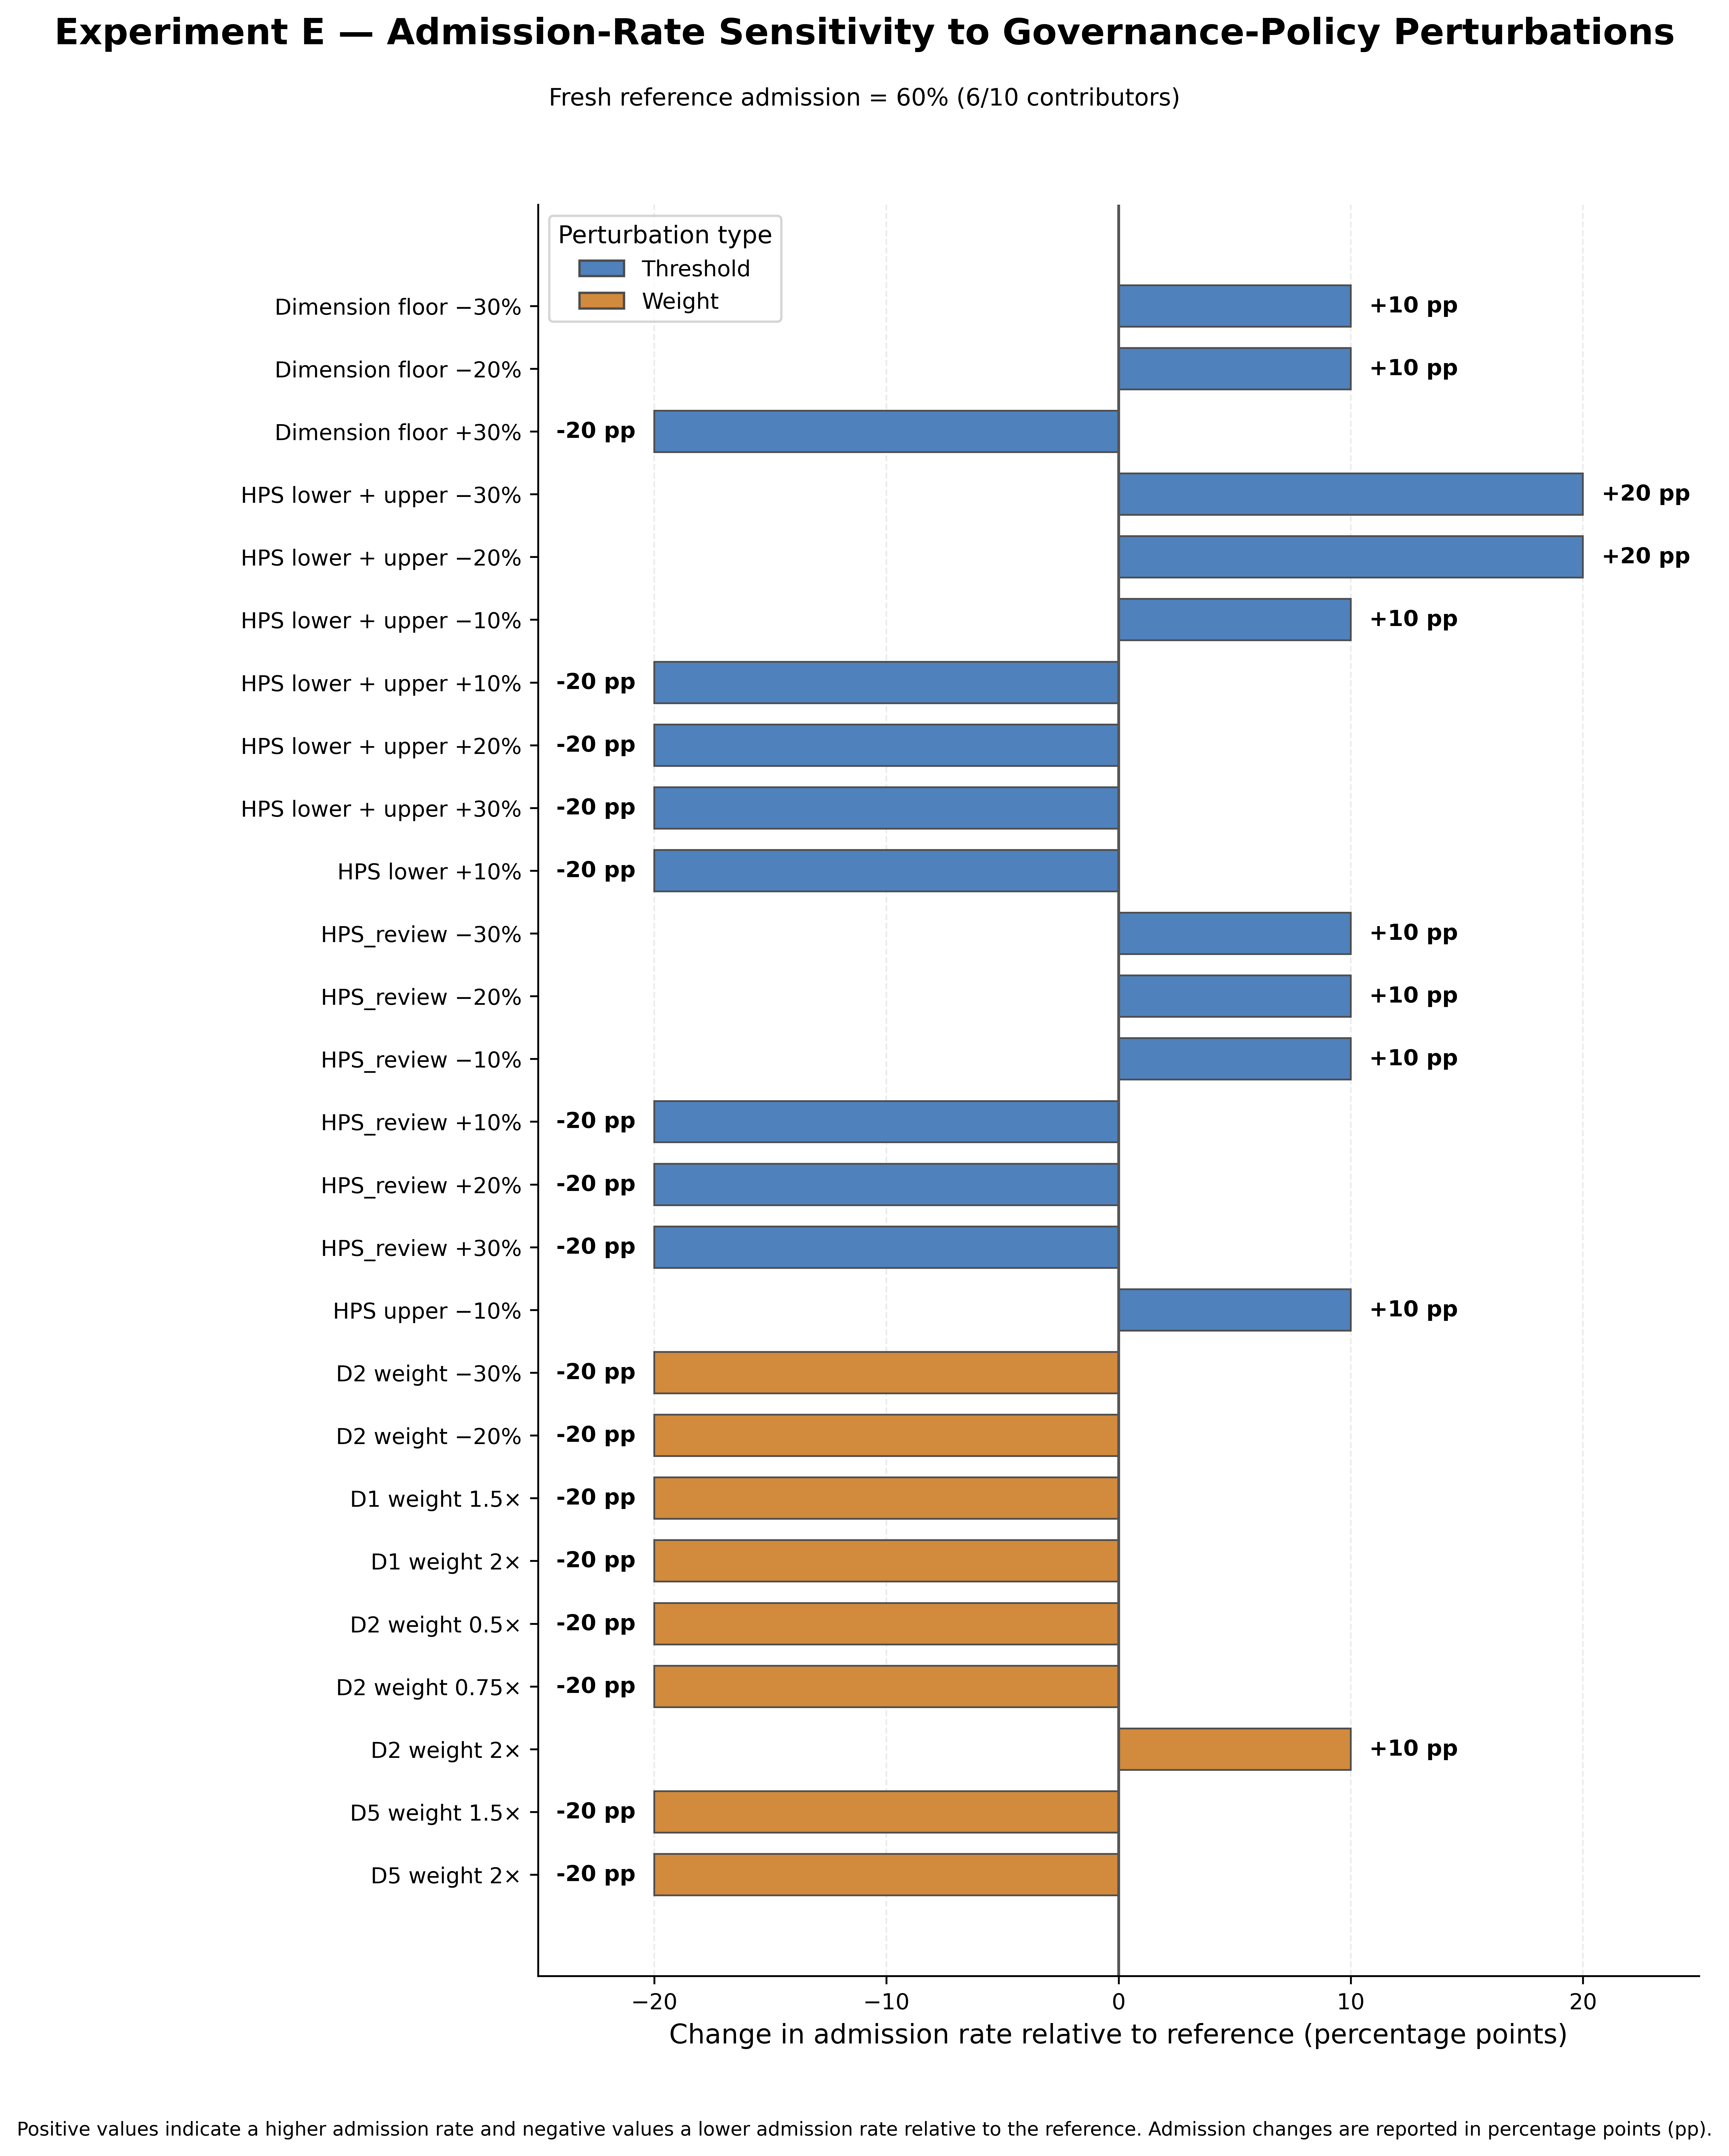


EXPERIMENT E — GOVERNANCE POLICY SENSITIVITY COMPLETE

REFERENCE
  admitted = 6/10
  admission rate = 60.0%

PERTURBATION SUMMARY


,Perturbation_Type,Tested,Admission_Changed,Shown_in_Figures
0,Threshold,26,17,17
1,Weight,66,9,9



CONFIGURATIONS SHOWN IN FIGURES


,configuration,family,Perturbation_Type,Display_Label,accepted_count,Admission_Rate_Pct,Delta_Admission_pp,Delta_Accuracy_pp,Delta_Macro_F1_pp,Delta_Macro_AUC_pp
0,DIMENSION_FLOOR_-30pct,DIMENSION_FLOOR,Threshold,Dimension floor −30%,7.0,70.0,10.0,2.1738,6.4588,0.0070
1,DIMENSION_FLOOR_-20pct,DIMENSION_FLOOR,Threshold,Dimension floor −20%,7.0,70.0,10.0,2.1738,6.4588,0.0070
2,DIMENSION_FLOOR_+30pct,DIMENSION_FLOOR,Threshold,Dimension floor +30%,4.0,40.0,-20.0,-3.9005,-1.3674,-0.7057
3,HPS_BOTH_-30pct,HPS_BOTH,Threshold,HPS lower + upper −30%,8.0,80.0,20.0,-1.1291,-0.2534,0.2692
4,HPS_BOTH_-20pct,HPS_BOTH,Threshold,HPS lower + upper −20%,8.0,80.0,20.0,-1.1291,-0.2534,0.2692
5,HPS_BOTH_-10pct,HPS_BOTH,Threshold,HPS lower + upper −10%,7.0,70.0,10.0,-0.2765,0.2139,0.3895
6,HPS_BOTH_+10pct,HPS_BOTH,Threshold,HPS lower + upper +10%,4.0,40.0,-20.0,-3.9005,-1.3674,-0.7057
7,HPS_BOTH_+20pct,HPS_BOTH,Threshold,HPS lower + upper +20%,4.0,40.0,-20.0,-3.9005,-1.3674,-0.7057
8,HPS_BOTH_+30pct,HPS_BOTH,Threshold,HPS lower + upper +30%,4.0,40.0,-20.0,-3.9005,-1.3674,-0.7057
9,HPS_LOWER_+10pct,HPS_LOWER,Threshold,HPS lower +10%,4.0,40.0,-20.0,-3.9005,-1.3674,-0.7057



FIGURE 1:
  Experiment_E_Policy_Perturbation_Admission_Bars.png
  Unit = percentage points (pp)

FIGURE 2:
  Experiment_E_Policy_Perturbation_Utility_Heatmap.png
  Unit = percentage points (pp)

OUTPUT QUALITY:
  PNG = 600 DPI
  PDF = vector

IMPORTANT:
  No genuine Threshold × Weight cross-perturbation rows were found in the uploaded Experiment-E results.
  HPS_BOTH is correctly treated as a threshold perturbation (HPS lower + upper thresholds changed together).

FINAL ZIP:
/content/Experiment_E_Policy_Perturbation_Bar_Heatmap_FINAL.zip



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# ======================================================================================
# EXPERIMENT E — GOVERNANCE POLICY SENSITIVITY TO PERTURBATIONS
# ======================================================================================
#
# FINAL PUBLICATION CELL
#
# ONE CELL -> TWO SEPARATE FIGURES
#
# FIGURE 1
# --------
# Experiment_E_Policy_Perturbation_Admission_Bars.png
#
# Horizontal bar chart:
#     Δ admission rate relative to reference
#     unit = percentage points (pp)
#
#
# FIGURE 2
# --------
# Experiment_E_Policy_Perturbation_Utility_Heatmap.png
#
# Heatmap:
#     Δ Accuracy
#     Δ Macro-F1
#     Δ Macro ROC-AUC
#
#     all expressed in percentage points (pp)
#
#
# FINAL EXPERIMENT-E DESIGN
# -------------------------
# K = 10
# Fresh reference cohort = 6/10 contributors = 60% admission
# 5 training seeds
# 4 federated rounds
#
#
# IMPORTANT
# ---------
# HPS_BOTH = simultaneous perturbation of HPS lower + upper thresholds.
# It is a THRESHOLD perturbation.
#
# It is NOT a threshold × weight interaction.
#
# A true Threshold × Weight family is shown only if such rows genuinely
# exist in the uploaded final Experiment-E result package.
#
#
# VISUALIZATION POLICY
# --------------------
# Only configurations that actually changed admission and/or downstream
# predictive utility are shown in the main figures.
#
# All valid tested configurations are retained in the exported CSV.
#
#
# OUTPUT
# ------
# 2 × PNG at 600 DPI
# 2 × vector PDF
# supporting CSV files
# 1 × ZIP package
# automatic ZIP download
# ======================================================================================


# ======================================================================================
# 1. IMPORTS
# ======================================================================================

import os
import re
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch


# ======================================================================================
# 2. PUBLICATION SETTINGS
# ======================================================================================

DPI = 600

K_SUBMISSIONS = 10


matplotlib.rcParams.update({

    "figure.dpi": DPI,

    "savefig.dpi": DPI,

    "pdf.fonttype": 42,

    "ps.fonttype": 42,

    "font.family": "DejaVu Sans",

    "font.size": 10.5,

    "axes.labelsize": 11.5,

    "xtick.labelsize": 9.5,

    "ytick.labelsize": 9.5,

    "legend.fontsize": 9.5,
})


OUT_DIR = (
    "/content"
    if os.path.isdir("/content")
    else "."
)


# ======================================================================================
# 3. UPLOAD FINAL EXPERIMENT-E ZIP
# ======================================================================================

try:

    from google.colab import files

except Exception:

    raise RuntimeError(
        "This cell is intended to run in Google Colab."
    )


print(
    "📤 Upload the FINAL Experiment-E RESULTS.zip"
)


uploaded = files.upload()


if len(uploaded) != 1:

    raise RuntimeError(
        "Please upload exactly one Experiment-E ZIP file."
    )


uploaded_name = next(
    iter(uploaded.keys())
)


if not uploaded_name.lower().endswith(
    ".zip"
):

    raise RuntimeError(
        "The uploaded file must be a .zip file."
    )


zip_path = os.path.join(
    OUT_DIR,
    uploaded_name,
)


with open(
    zip_path,
    "wb",
) as f:

    f.write(
        uploaded[
            uploaded_name
        ]
    )


print(
    f"✅ Uploaded: {uploaded_name}"
)


# ======================================================================================
# 4. EXTRACT FINAL RESULTS PACKAGE
# ======================================================================================

extract_dir = Path(

    tempfile.mkdtemp(
        prefix="TADP_Experiment_E_Final_"
    )
)


with zipfile.ZipFile(
    zip_path,
    "r",
) as zf:

    zf.extractall(
        extract_dir
    )


print(
    "✅ Extracted to:"
)

print(
    extract_dir
)


# ======================================================================================
# 5. FIND FINAL POLICY-IMPACT TABLE
# ======================================================================================

TARGET_FILE = (
    "policy_admission_utility_impact_vs_fresh_reference.csv"
)


matches = list(

    extract_dir.rglob(
        TARGET_FILE
    )
)


if not matches:

    raise FileNotFoundError(

        f"Could not find '{TARGET_FILE}' "
        "inside the uploaded Experiment-E package."
    )


impact_path = matches[0]


print(
    "\n✅ Final Experiment-E impact table:"
)

print(
    impact_path
)


df = pd.read_csv(
    impact_path
)


# ======================================================================================
# 6. VALIDATE REQUIRED COLUMNS
# ======================================================================================

required_columns = {

    "configuration",

    "family",

    "valid_policy",

    "accepted_count",

    "delta_accuracy_mean",

    "delta_f1_macro_mean",

    "delta_roc_auc_ovr_macro_mean",
}


missing_columns = (

    required_columns

    - set(
        df.columns
    )
)


if missing_columns:

    raise RuntimeError(

        "Missing required columns:\n"

        + "\n".join(
            sorted(
                missing_columns
            )
        )
    )


# ======================================================================================
# 7. KEEP VALID POLICY CONDITIONS ONLY
# ======================================================================================

valid_policy_mask = (

    df[
        "valid_policy"
    ]

    .astype(str)

    .str.strip()

    .str.lower()

    .isin([
        "true",
        "1",
        "yes",
    ])
)


df = df.loc[
    valid_policy_mask
].copy()


# ======================================================================================
# 8. GET FRESH EXPERIMENT-E REFERENCE
# ======================================================================================

reference = df.loc[

    df[
        "configuration"
    ]

    .astype(str)

    .str.upper()

    .eq(
        "REFERENCE"
    )

].copy()


if reference.empty:

    raise RuntimeError(
        "REFERENCE configuration was not found."
    )


REFERENCE_N = float(

    reference[
        "accepted_count"
    ]
    .iloc[0]
)


REFERENCE_ADMISSION_PCT = (

    100.0

    * REFERENCE_N

    / K_SUBMISSIONS
)


print(
    "\n"
    + "=" * 100
)

print(
    "FRESH EXPERIMENT-E REFERENCE"
)

print(
    "=" * 100
)


print(
    f"Reference admitted contributors = "
    f"{REFERENCE_N:.0f}/{K_SUBMISSIONS}"
)


print(
    f"Reference admission rate = "
    f"{REFERENCE_ADMISSION_PCT:.1f}%"
)


# ======================================================================================
# 9. REMOVE REFERENCE AND LODO
# ======================================================================================
#
# LODO is intentionally excluded.
#
# It belongs to the separate:
# Experiment_E_LODO_Dimension_Influence figure.
# ======================================================================================

pert = df.loc[

    ~df[
        "configuration"
    ]

    .astype(str)

    .str.upper()

    .eq(
        "REFERENCE"
    )

].copy()


pert = pert.loc[

    ~pert[
        "family"
    ]

    .astype(str)

    .str.upper()

    .eq(
        "LODO"
    )

].copy()


# ======================================================================================
# 10. COMPUTE ADMISSION RATE AND Δ ADMISSION IN PERCENTAGE POINTS
# ======================================================================================

pert[
    "Admission_Rate_Pct"
] = (

    100.0

    * pert[
        "accepted_count"
    ]

    / K_SUBMISSIONS
)


pert[
    "Delta_Admission_pp"
] = (

    pert[
        "Admission_Rate_Pct"
    ]

    - REFERENCE_ADMISSION_PCT
)


# ======================================================================================
# 11. CONVERT PREDICTIVE DELTAS TO PERCENTAGE POINTS
# ======================================================================================

pert[
    "Delta_Accuracy_pp"
] = (

    100.0

    * pert[
        "delta_accuracy_mean"
    ]
)


pert[
    "Delta_Macro_F1_pp"
] = (

    100.0

    * pert[
        "delta_f1_macro_mean"
    ]
)


pert[
    "Delta_Macro_AUC_pp"
] = (

    100.0

    * pert[
        "delta_roc_auc_ovr_macro_mean"
    ]
)


# ======================================================================================
# 12. CLASSIFY PERTURBATION TYPE
# ======================================================================================

family_upper = (

    pert[
        "family"
    ]

    .astype(str)

    .str.upper()
)


THRESHOLD_FAMILIES = {

    "HPS_LOWER",

    "HPS_UPPER",

    "HPS_BOTH",

    "HPS_REVIEW_THRESHOLD",

    "REVIEW_THRESHOLD",

    "DIMENSION_FLOOR",
}


pert[
    "Perturbation_Type"
] = "Other"


# Threshold family
pert.loc[

    family_upper.isin(
        THRESHOLD_FAMILIES
    ),

    "Perturbation_Type"

] = "Threshold"


# Genuine threshold × weight family
joint_mask = (

    family_upper

    .str.contains(
        "JOINT",
        na=False,
    )

    &

    family_upper

    .str.contains(
        "WEIGHT",
        na=False,
    )
)


pert.loc[

    joint_mask,

    "Perturbation_Type"

] = "Threshold × Weight"


# Weight family
weight_mask = (

    family_upper

    .str.contains(
        "WEIGHT",
        na=False,
    )

    &

    ~joint_mask
)


pert.loc[

    weight_mask,

    "Perturbation_Type"

] = "Weight"


# ======================================================================================
# 13. REPORT UNCLASSIFIED ROWS
# ======================================================================================

unknown = pert.loc[

    pert[
        "Perturbation_Type"
    ]

    .eq(
        "Other"
    )

].copy()


if not unknown.empty:

    print(
        "\n⚠ Unclassified perturbation families:"
    )

    print(

        sorted(

            unknown[
                "family"
            ]

            .astype(str)

            .unique()

            .tolist()
        )
    )


# Keep only actual policy perturbation families
pert = pert.loc[

    ~pert[
        "Perturbation_Type"
    ]

    .eq(
        "Other"
    )

].copy()


# ======================================================================================
# 14. HELPER — SIGNED PERCENTAGE LABEL
# ======================================================================================

def signed_pct(
    value
):

    try:

        value = int(
            round(
                float(
                    value
                )
            )
        )

    except Exception:

        return ""


    return (

        f"{value:+d}%"

        .replace(
            "-",
            "−"
        )
    )


# ======================================================================================
# 15. HELPER — DIMENSION LABEL
# ======================================================================================

def dimension_label(
    value
):

    value = str(
        value
    ).lower()


    match = re.search(

        r"dim([1-6])",

        value,
    )


    if match:

        return (
            "D"
            + match.group(1)
        )


    return ""


# ======================================================================================
# 16. BUILD PROFESSIONAL DISPLAY LABELS
# ======================================================================================

def build_display_label(
    row
):

    family = str(
        row[
            "family"
        ]
    ).upper()


    configuration = str(
        row[
            "configuration"
        ]
    )


    perturb_pct = row.get(
        "perturbation_pct",
        np.nan,
    )


    pct = signed_pct(
        perturb_pct
    )


    # ------------------------------------------------------------------
    # THRESHOLDS
    # ------------------------------------------------------------------

    if family == "HPS_LOWER":

        return (
            f"HPS lower {pct}"
        )


    if family == "HPS_UPPER":

        return (
            f"HPS upper {pct}"
        )


    if family == "HPS_BOTH":

        return (
            f"HPS lower + upper {pct}"
        )


    if family in {

        "HPS_REVIEW_THRESHOLD",

        "REVIEW_THRESHOLD",
    }:

        return (
            f"HPS_review {pct}"
        )


    if family == "DIMENSION_FLOOR":

        return (
            f"Dimension floor {pct}"
        )


    # ------------------------------------------------------------------
    # WEIGHT PERTURBATIONS
    # ------------------------------------------------------------------

    if "WEIGHT" in family:

        dim = dimension_label(

            row.get(
                "weight_dimension",
                ""
            )
        )


        if not dim:

            dim = dimension_label(
                configuration
            )


        # Stress multiplier
        if "STRESS" in family:

            try:

                multiplier = float(

                    row.get(
                        "weight_multiplier",
                        np.nan,
                    )
                )


                if np.isfinite(
                    multiplier
                ):

                    return (
                        f"{dim} weight {multiplier:g}×"
                    )

            except Exception:

                pass


        # Ordinary percentage perturbation
        if pct:

            return (
                f"{dim} weight {pct}"
            )


    # ------------------------------------------------------------------
    # FALLBACK
    # ------------------------------------------------------------------

    return (

        configuration

        .replace(
            "_",
            " "
        )

        .replace(
            "pct",
            "%"
        )
    )


pert[
    "Display_Label"
] = pert.apply(

    build_display_label,

    axis=1,
)


# ======================================================================================
# 17. IDENTIFY CONFIGURATIONS WITH AN OBSERVED EFFECT
# ======================================================================================
#
# Configurations with:
#
#   Δ admission = 0 pp
#   Δ Accuracy = 0 pp
#   Δ F1 = 0 pp
#   Δ AUC = 0 pp
#
# are omitted from the two main visualizations.
#
# They remain in the exported full CSV.
# ======================================================================================

EPS = 1e-12


impact_mask = (

    pert[
        "Delta_Admission_pp"
    ]

    .abs()

    .gt(
        EPS
    )

    |

    pert[
        "Delta_Accuracy_pp"
    ]

    .abs()

    .gt(
        EPS
    )

    |

    pert[
        "Delta_Macro_F1_pp"
    ]

    .abs()

    .gt(
        EPS
    )

    |

    pert[
        "Delta_Macro_AUC_pp"
    ]

    .abs()

    .gt(
        EPS
    )
)


impact = pert.loc[
    impact_mask
].copy()


if impact.empty:

    raise RuntimeError(
        "No perturbation produced an observed effect."
    )


# ======================================================================================
# 18. ORDER CONFIGURATIONS
# ======================================================================================

TYPE_ORDER = {

    "Threshold":
        0,

    "Weight":
        1,

    "Threshold × Weight":
        2,
}


impact[
    "_type_order"
] = (

    impact[
        "Perturbation_Type"
    ]

    .map(
        TYPE_ORDER
    )
)


if "perturbation_pct" not in impact.columns:

    impact[
        "perturbation_pct"
    ] = 0


impact[
    "_pct_sort"
] = pd.to_numeric(

    impact[
        "perturbation_pct"
    ],

    errors="coerce",
).fillna(
    0
)


impact = (

    impact

    .sort_values(

        [
            "_type_order",

            "family",

            "_pct_sort",

            "configuration",
        ]
    )

    .reset_index(
        drop=True
    )
)


# ======================================================================================
# 19. COLORS
# ======================================================================================

GROUP_COLORS = {

    "Threshold":
        "#4F81BD",

    "Weight":
        "#D28A3D",

    "Threshold × Weight":
        "#8064A2",
}


EDGE_COLOR = "#4D4D4D"

GRID_COLOR = "#C8C8C8"


# ======================================================================================
# 20. SUMMARY TABLE
# ======================================================================================

summary = (

    pert

    .groupby(
        "Perturbation_Type",
        sort=False,
    )

    .agg(

        Tested=(
            "configuration",
            "count",
        ),

        Admission_Changed=(
            "Delta_Admission_pp",

            lambda x: int(

                np.sum(

                    np.abs(

                        x.to_numpy(
                            dtype=float
                        )
                    )

                    > EPS
                )
            ),
        ),
    )

    .reset_index()
)


shown_counts = (

    impact[
        "Perturbation_Type"
    ]

    .value_counts()
)


summary[
    "Shown_in_Figures"
] = (

    summary[
        "Perturbation_Type"
    ]

    .map(
        shown_counts
    )

    .fillna(
        0
    )

    .astype(
        int
    )
)


# ======================================================================================
# FIGURE 1
# ADMISSION-RATE SENSITIVITY — HORIZONTAL BAR CHART
# ======================================================================================

n_rows = len(
    impact
)


fig1_height = max(

    5.8,

    0.43
    * n_rows
    + 2.0,
)


fig1, ax1 = plt.subplots(

    figsize=(
        10.8,
        fig1_height,
    ),

    dpi=DPI,
)


y = np.arange(
    n_rows
)


bar_colors = [

    GROUP_COLORS[
        ptype
    ]

    for ptype in impact[
        "Perturbation_Type"
    ]
]


bars = ax1.barh(

    y,

    impact[
        "Delta_Admission_pp"
    ],

    height=0.66,

    color=bar_colors,

    edgecolor=EDGE_COLOR,

    linewidth=0.75,
)


# Zero reference line
ax1.axvline(

    0,

    color="#555555",

    linewidth=1.2,
)


# Y-axis
ax1.set_yticks(
    y
)


ax1.set_yticklabels(

    impact[
        "Display_Label"
    ],

    fontsize=9.4,
)


ax1.invert_yaxis()


# X-axis
ax1.set_xlabel(

    "Change in admission rate relative to reference (percentage points)",

    fontsize=11.5,
)


# Grid
ax1.grid(

    axis="x",

    linestyle="--",

    linewidth=0.7,

    alpha=0.35,

    color=GRID_COLOR,
)


ax1.set_axisbelow(
    True
)


ax1.spines[
    "top"
].set_visible(
    False
)


ax1.spines[
    "right"
].set_visible(
    False
)


# ======================================================================================
# 21. BAR LIMITS
# ======================================================================================

max_abs_admission = max(

    10.0,

    float(

        impact[
            "Delta_Admission_pp"
        ]

        .abs()

        .max()
    )
)


x_margin = 5.0


ax1.set_xlim(

    -max_abs_admission
    - x_margin,

    max_abs_admission
    + x_margin,
)


# ======================================================================================
# 22. BAR VALUE LABELS
# ======================================================================================

for bar, value in zip(

    bars,

    impact[
        "Delta_Admission_pp"
    ],
):

    value = float(
        value
    )


    if value >= 0:

        x_text = (
            value
            + 0.8
        )

        ha = "left"

    else:

        x_text = (
            value
            - 0.8
        )

        ha = "right"


    ax1.text(

        x_text,

        bar.get_y()
        + bar.get_height() / 2,

        f"{value:+.0f} pp",

        ha=ha,

        va="center",

        fontsize=9.5,

        fontweight="bold",
    )


# ======================================================================================
# 23. BAR LEGEND
# ======================================================================================

present_types = [

    t

    for t in [

        "Threshold",

        "Weight",

        "Threshold × Weight",
    ]

    if t in set(

        impact[
            "Perturbation_Type"
        ]
    )
]


legend_handles = [

    Patch(

        facecolor=GROUP_COLORS[
            t
        ],

        edgecolor=EDGE_COLOR,

        label=t,
    )

    for t in present_types
]


ax1.legend(

    handles=legend_handles,

    loc="best",

    frameon=True,

    title="Perturbation type",
)


# ======================================================================================
# 24. BAR TITLE
# ======================================================================================

fig1.suptitle(

    "Experiment E — Admission-Rate Sensitivity to Governance-Policy Perturbations",

    fontsize=15.5,

    fontweight="bold",

    y=0.975,
)


fig1.text(

    0.5,

    0.935,

    (
        f"Fresh reference admission = "
        f"{REFERENCE_ADMISSION_PCT:.0f}% "
        f"({REFERENCE_N:.0f}/{K_SUBMISSIONS} contributors)"
    ),

    ha="center",

    fontsize=10.2,
)


fig1.text(

    0.5,

    0.018,

    (
        "Positive values indicate a higher admission rate and negative values "
        "a lower admission rate relative to the reference. "
        "Admission changes are reported in percentage points (pp)."
    ),

    ha="center",

    fontsize=8.2,
)


fig1.subplots_adjust(

    left=0.32,

    right=0.96,

    bottom=0.09,

    top=0.89,
)


# ======================================================================================
# 25. SAVE BAR FIGURE
# ======================================================================================

bar_png = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Admission_Bars.png",
)


bar_pdf = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Admission_Bars.pdf",
)


fig1.savefig(

    bar_png,

    dpi=600,

    bbox_inches="tight",

    facecolor="white",
)


fig1.savefig(

    bar_pdf,

    bbox_inches="tight",

    facecolor="white",
)


plt.show()


# ======================================================================================
# FIGURE 2
# PREDICTIVE-UTILITY SENSITIVITY — HEATMAP
# ======================================================================================

heatmap_columns = [

    "Delta_Accuracy_pp",

    "Delta_Macro_F1_pp",

    "Delta_Macro_AUC_pp",
]


heatmap_labels = [

    "Δ Accuracy\n(pp)",

    "Δ Macro-F1\n(pp)",

    "Δ Macro ROC-AUC\n(pp)",
]


matrix = (

    impact[
        heatmap_columns
    ]

    .to_numpy(
        dtype=float
    )
)


# ======================================================================================
# 26. HEATMAP SCALE — SYMMETRIC AROUND ZERO
# ======================================================================================

max_abs_utility = float(

    np.nanmax(

        np.abs(
            matrix
        )
    )
)


if (

    not np.isfinite(
        max_abs_utility
    )

    or

    max_abs_utility == 0
):

    max_abs_utility = 1.0


norm = TwoSlopeNorm(

    vmin=-max_abs_utility,

    vcenter=0.0,

    vmax=max_abs_utility,
)


# ======================================================================================
# 27. CREATE HEATMAP
# ======================================================================================

fig2_height = max(

    5.8,

    0.43
    * n_rows
    + 2.0,
)


fig2, ax2 = plt.subplots(

    figsize=(
        10.3,
        fig2_height,
    ),

    dpi=DPI,
)


im = ax2.imshow(

    matrix,

    cmap="RdBu_r",

    norm=norm,

    aspect="auto",
)


# ======================================================================================
# 28. HEATMAP AXES
# ======================================================================================

ax2.set_xticks(

    np.arange(
        len(
            heatmap_labels
        )
    )
)


ax2.set_xticklabels(

    heatmap_labels,

    fontsize=10.3,
)


ax2.set_yticks(

    np.arange(
        n_rows
    )
)


ax2.set_yticklabels(

    impact[
        "Display_Label"
    ],

    fontsize=9.3,
)


# Color row labels by perturbation family
for tick, ptype in zip(

    ax2.get_yticklabels(),

    impact[
        "Perturbation_Type"
    ],
):

    tick.set_color(

        GROUP_COLORS[
            ptype
        ]
    )


# ======================================================================================
# 29. HEATMAP CELL VALUES
# ======================================================================================

for row_index in range(
    matrix.shape[0]
):

    for col_index in range(
        matrix.shape[1]
    ):

        value = float(

            matrix[
                row_index,
                col_index
            ]
        )


        strong_cell = (

            abs(
                value
            )

            >=

            (
                0.52
                * max_abs_utility
            )
        )


        text_color = (

            "white"

            if strong_cell

            else "#222222"
        )


        ax2.text(

            col_index,

            row_index,

            f"{value:+.2f} pp",

            ha="center",

            va="center",

            fontsize=8.8,

            fontweight="bold",

            color=text_color,
        )


# ======================================================================================
# 30. ADD GROUP SEPARATORS
# ======================================================================================

types = (

    impact[
        "Perturbation_Type"
    ]

    .tolist()
)


for row_index in range(
    1,
    len(
        types
    )
):

    if (

        types[
            row_index
        ]

        !=

        types[
            row_index - 1
        ]
    ):

        ax2.axhline(

            row_index
            - 0.5,

            color="white",

            linewidth=3.0,
        )


# ======================================================================================
# 31. COLORBAR
# ======================================================================================

cbar = fig2.colorbar(

    im,

    ax=ax2,

    fraction=0.038,

    pad=0.03,
)


cbar.set_label(

    "Change relative to reference (percentage points)",

    fontsize=10.5,
)


# ======================================================================================
# 32. HEATMAP TITLE
# ======================================================================================

fig2.suptitle(

    "Experiment E — Predictive-Utility Sensitivity to Governance-Policy Perturbations",

    fontsize=15.5,

    fontweight="bold",

    y=0.975,
)


fig2.text(

    0.5,

    0.935,

    (
        "Downstream predictive change associated with each "
        "perturbation-induced admitted cohort"
    ),

    ha="center",

    fontsize=10.2,
)


fig2.text(

    0.5,

    0.018,

    (
        "Red indicates an increase and blue a decrease relative to the fresh reference. "
        "All predictive changes are reported in percentage points (pp). "
        "Rows correspond directly to the admission-sensitivity figure."
    ),

    ha="center",

    fontsize=8.2,
)


fig2.subplots_adjust(

    left=0.34,

    right=0.91,

    bottom=0.09,

    top=0.89,
)


# ======================================================================================
# 33. SAVE HEATMAP
# ======================================================================================

heatmap_png = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Utility_Heatmap.png",
)


heatmap_pdf = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Utility_Heatmap.pdf",
)


fig2.savefig(

    heatmap_png,

    dpi=600,

    bbox_inches="tight",

    facecolor="white",
)


fig2.savefig(

    heatmap_pdf,

    bbox_inches="tight",

    facecolor="white",
)


plt.show()


# ======================================================================================
# 34. EXPORT ALL VALID PERTURBATION RESULTS
# ======================================================================================

all_csv = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_All_Valid_Configurations.csv",
)


pert.to_csv(

    all_csv,

    index=False,
)


# ======================================================================================
# 35. EXPORT ONLY CONFIGURATIONS SHOWN IN FIGURES
# ======================================================================================

shown_csv = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Figure_Data.csv",
)


figure_columns = [

    "configuration",

    "family",

    "Perturbation_Type",

    "Display_Label",

    "accepted_count",

    "Admission_Rate_Pct",

    "Delta_Admission_pp",

    "Delta_Accuracy_pp",

    "Delta_Macro_F1_pp",

    "Delta_Macro_AUC_pp",
]


impact[
    figure_columns
].to_csv(

    shown_csv,

    index=False,
)


# ======================================================================================
# 36. EXPORT SUMMARY
# ======================================================================================

summary_csv = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Summary.csv",
)


summary.to_csv(

    summary_csv,

    index=False,
)


# ======================================================================================
# 37. CREATE ZIP
# ======================================================================================

out_zip = os.path.join(

    OUT_DIR,

    "Experiment_E_Policy_Perturbation_Bar_Heatmap_FINAL.zip",
)


with zipfile.ZipFile(

    out_zip,

    "w",

    compression=zipfile.ZIP_DEFLATED,

) as zf:


    for path in [

        bar_png,

        bar_pdf,

        heatmap_png,

        heatmap_pdf,

        all_csv,

        shown_csv,

        summary_csv,

    ]:

        zf.write(

            path,

            arcname=os.path.basename(
                path
            ),
        )


# ======================================================================================
# 38. FINAL VERIFICATION
# ======================================================================================

print(
    "\n"
    + "=" * 115
)


print(
    "EXPERIMENT E — GOVERNANCE POLICY SENSITIVITY COMPLETE"
)


print(
    "=" * 115
)


print(
    "\nREFERENCE"
)


print(
    f"  admitted = "
    f"{REFERENCE_N:.0f}/{K_SUBMISSIONS}"
)


print(
    f"  admission rate = "
    f"{REFERENCE_ADMISSION_PCT:.1f}%"
)


print(
    "\nPERTURBATION SUMMARY"
)


display(
    summary
)


print(
    "\nCONFIGURATIONS SHOWN IN FIGURES"
)


display(

    impact[
        figure_columns
    ]

    .round(
        4
    )
)


print(
    "\nFIGURE 1:"
)


print(
    "  Experiment_E_Policy_Perturbation_Admission_Bars.png"
)


print(
    "  Unit = percentage points (pp)"
)


print(
    "\nFIGURE 2:"
)


print(
    "  Experiment_E_Policy_Perturbation_Utility_Heatmap.png"
)


print(
    "  Unit = percentage points (pp)"
)


print(
    "\nOUTPUT QUALITY:"
)


print(
    "  PNG = 600 DPI"
)


print(
    "  PDF = vector"
)


if not (

    pert[
        "Perturbation_Type"
    ]

    .eq(
        "Threshold × Weight"
    )

    .any()
):

    print(
        "\nIMPORTANT:"
    )

    print(
        "  No genuine Threshold × Weight cross-perturbation "
        "rows were found in the uploaded Experiment-E results."
    )

    print(
        "  HPS_BOTH is correctly treated as a threshold perturbation "
        "(HPS lower + upper thresholds changed together)."
    )


print(
    "\nFINAL ZIP:"
)


print(
    out_zip
)


# ======================================================================================
# 39. AUTOMATIC DOWNLOAD
# ======================================================================================

print(
    "\nDownloading final 600-DPI figure package..."
)


files.download(
    out_zip
)

📤 Upload the FINAL Experiment-E RESULTS.zip


Saving TADP_EXPERIMENT_E_TADP-E-FINAL-A1A2-28F-HPSREVIEW-OPTIONA-K10-5SEED-4ROUND_RESULTS(1).zip to TADP_EXPERIMENT_E_TADP-E-FINAL-A1A2-28F-HPSREVIEW-OPTIONA-K10-5SEED-4ROUND_RESULTS(1) (4).zip

✅ Extracted final Experiment E:
/tmp/TADP_E2_INPUT_d3wixmd1

✅ Loaded final Experiment-E artifacts
   Factor evidence: /tmp/TADP_E2_INPUT_d3wixmd1/all_28_factor_evidence_by_client.csv
   Policy impact: /tmp/TADP_E2_INPUT_d3wixmd1/policy_admission_utility_impact_vs_fresh_reference.csv
   Fresh cohort performance: /tmp/TADP_E2_INPUT_d3wixmd1/fresh_unique_cohort_performance.csv

OFFICIAL FRESH EXPERIMENT-E REFERENCE
Cohort: ['A', 'B', 'G', 'H', 'I', 'J']
Admission: 6/10 = 60.0%

✅ Reference-policy reconstruction audit: PASS

✅ All HPS-only cohorts already have five fresh Experiment-E training runs.
   No additional model training is required.

✅ Official full-policy LODO cohorts loaded:


,removed_dimension,accepted_count,normalized_cohort_key
0,dim1,8.0,A;B;E;F;G;H;I;J
1,dim2,4.0,B;G;I;J
2,dim3,6.0,A;B;G;H;I;J
3,dim4,7.0,A;B;C;G;H;I;J
4,dim5,7.0,A;B;E;G;H;I;J
5,dim6,6.0,A;B;G;H;I;J



✅ Full-policy LODO five-seed utility audit: PASS

EXPERIMENT E2 — HPS-ONLY ABLATION vs FULL-POLICY LODO


,Dimension,Dimension_Name,HPS_Only_Admitted,HPS_Only_Delta_Admission_pp,Full_LODO_Admitted,Full_LODO_Delta_Admission_pp,HPS_Only_Delta_Accuracy_pp,Full_LODO_Delta_Accuracy_pp,HPS_Only_Delta_MacroF1_pp,Full_LODO_Delta_MacroF1_pp,HPS_Only_Delta_MacroAUC_pp,Full_LODO_Delta_MacroAUC_pp,Observed_Mechanism_Pattern
0,D1,Source Reliability,7,10.0,8,20.0,-0.2765,0.3094,0.2139,2.2083,0.3895,0.3695,"Both alter admission, but full-policy removal ..."
1,D2,Data Quality and Health,6,0.0,4,-20.0,0.0000,-3.9005,0.0000,-1.3674,0.0000,-0.7057,Effect emerges only under full-policy removal
2,D3,Documentation Practices,6,0.0,6,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,No admission change under either ablation
3,D4,Timeliness and Refresh Rate,6,0.0,7,10.0,0.0000,2.1738,0.0000,6.4588,0.0000,0.0070,Effect emerges only under full-policy removal
4,D5,Regulatory and Compliance Alignment,7,10.0,7,10.0,-0.2765,-0.2765,0.2139,0.2139,0.3895,0.3895,Admission effect reproduced by main-HPS ablation
5,D6,Context and Usage Constraints,6,0.0,6,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,No admission change under either ablation


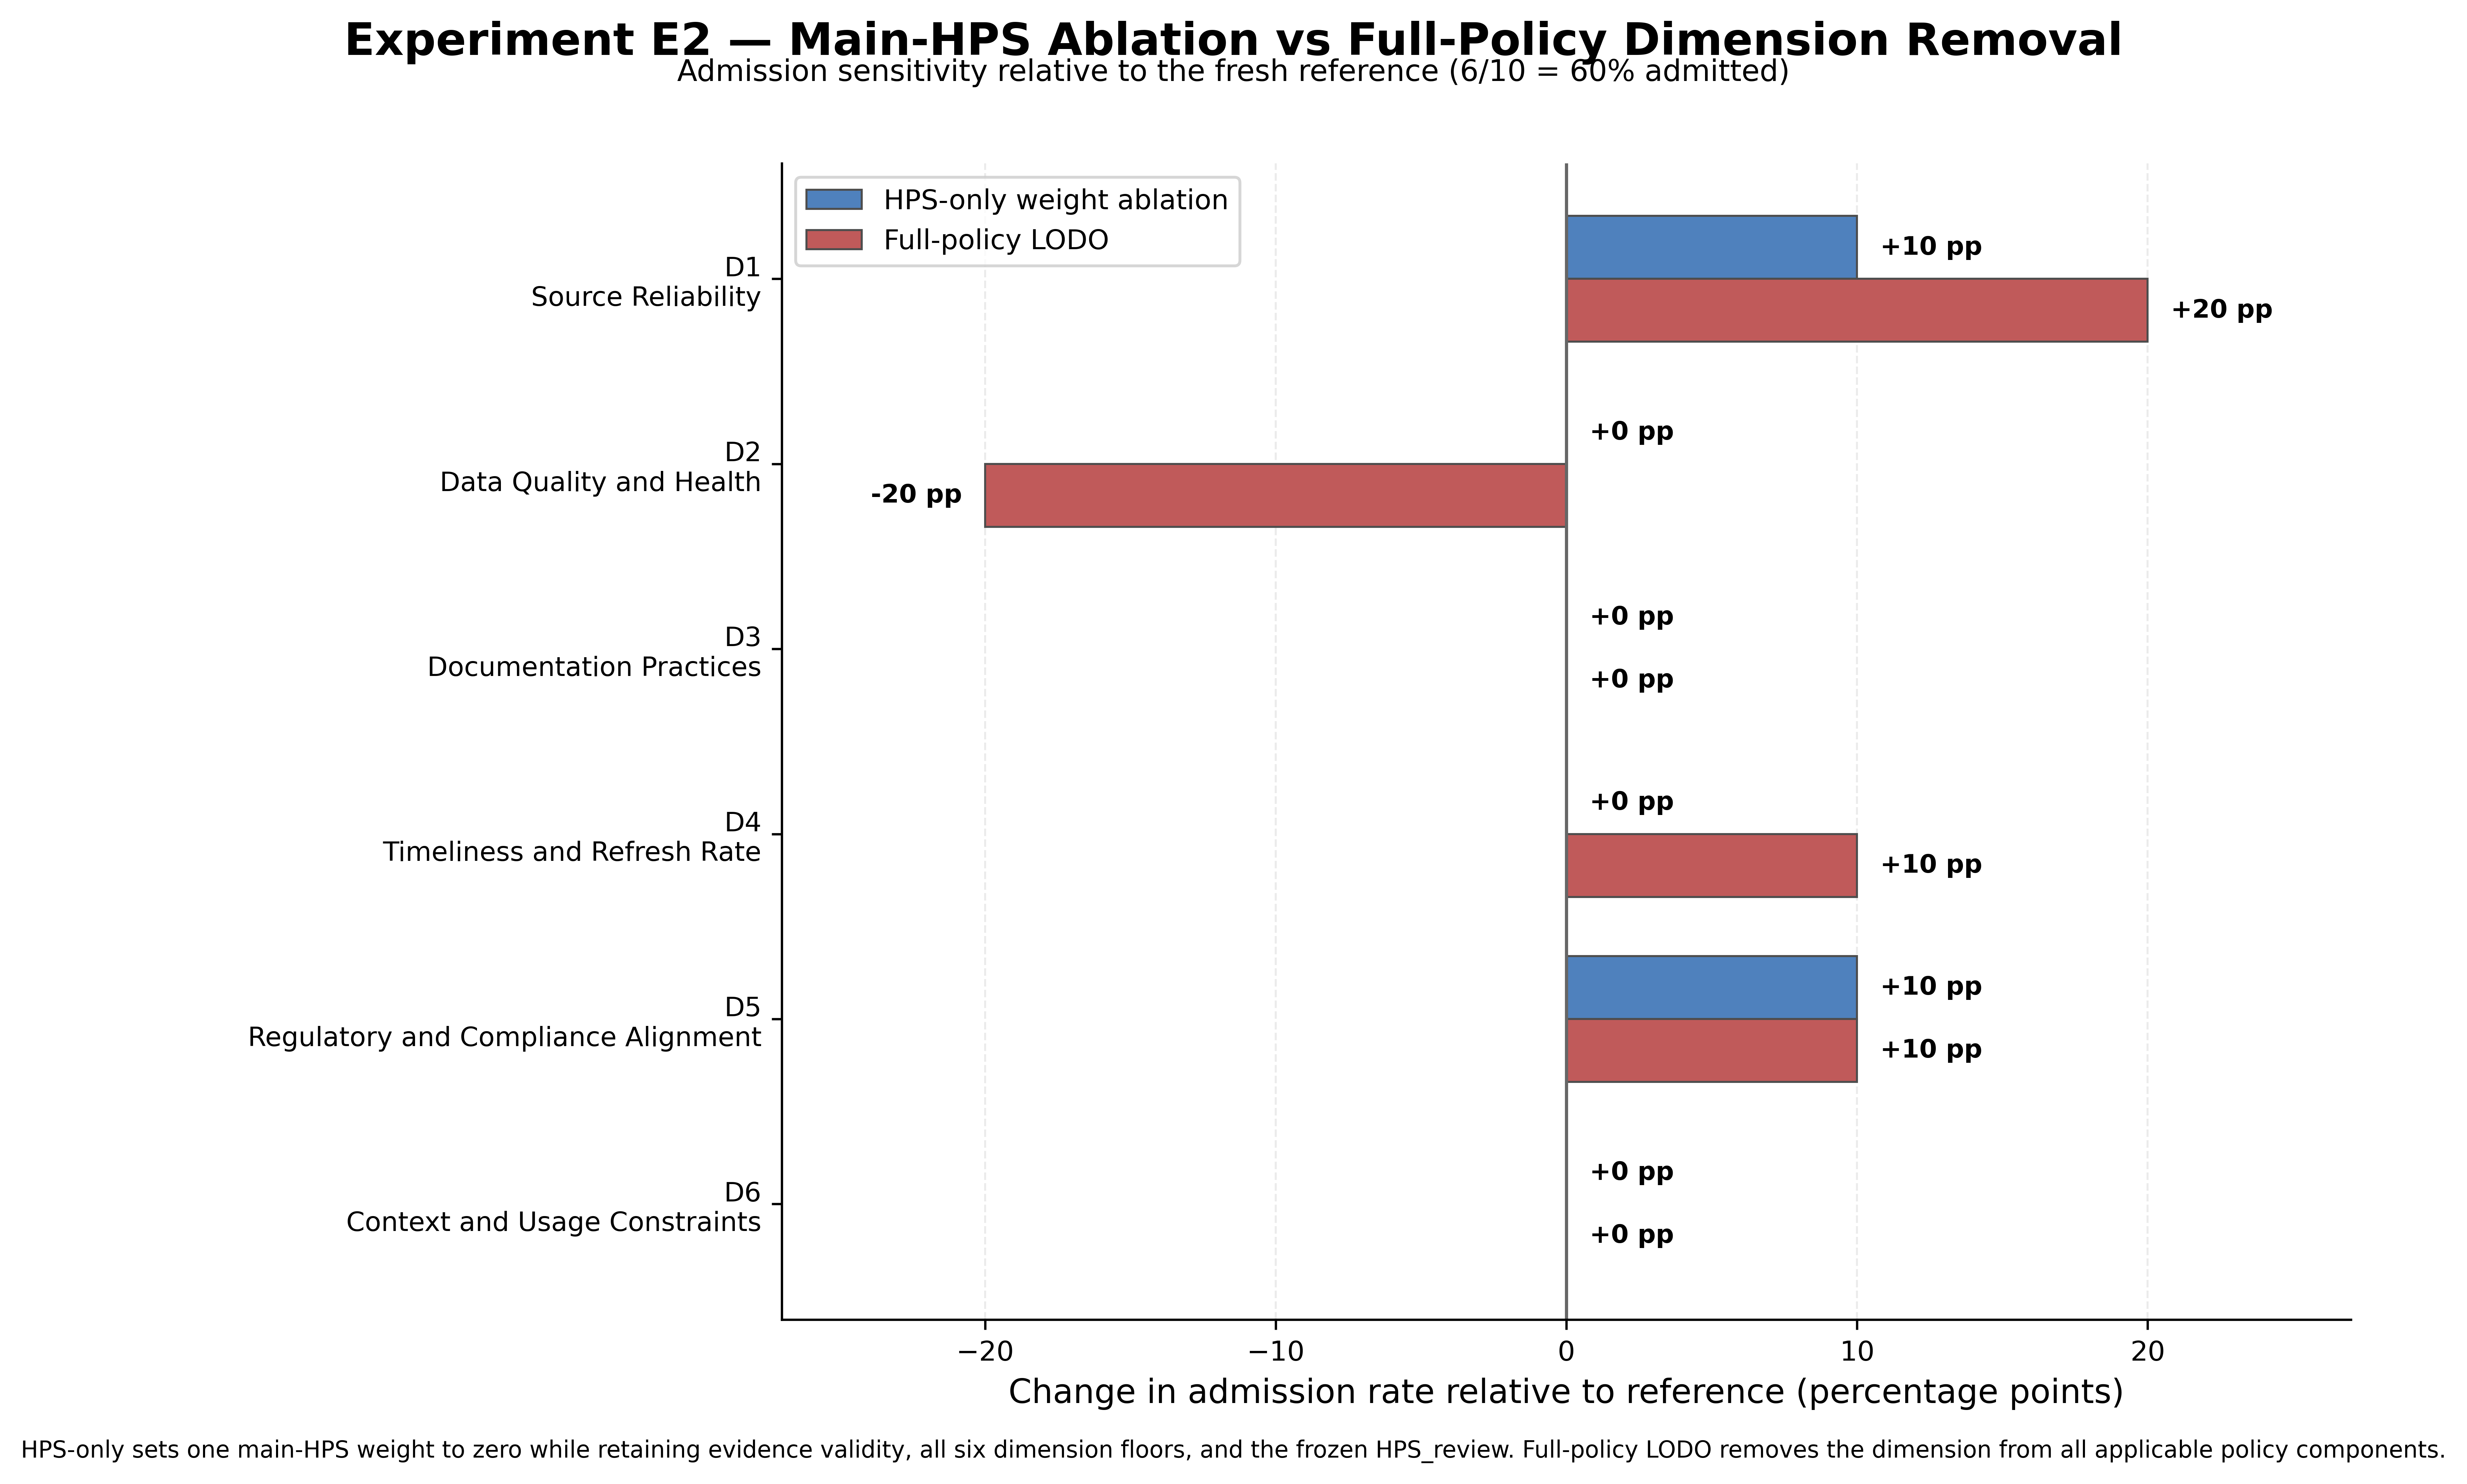

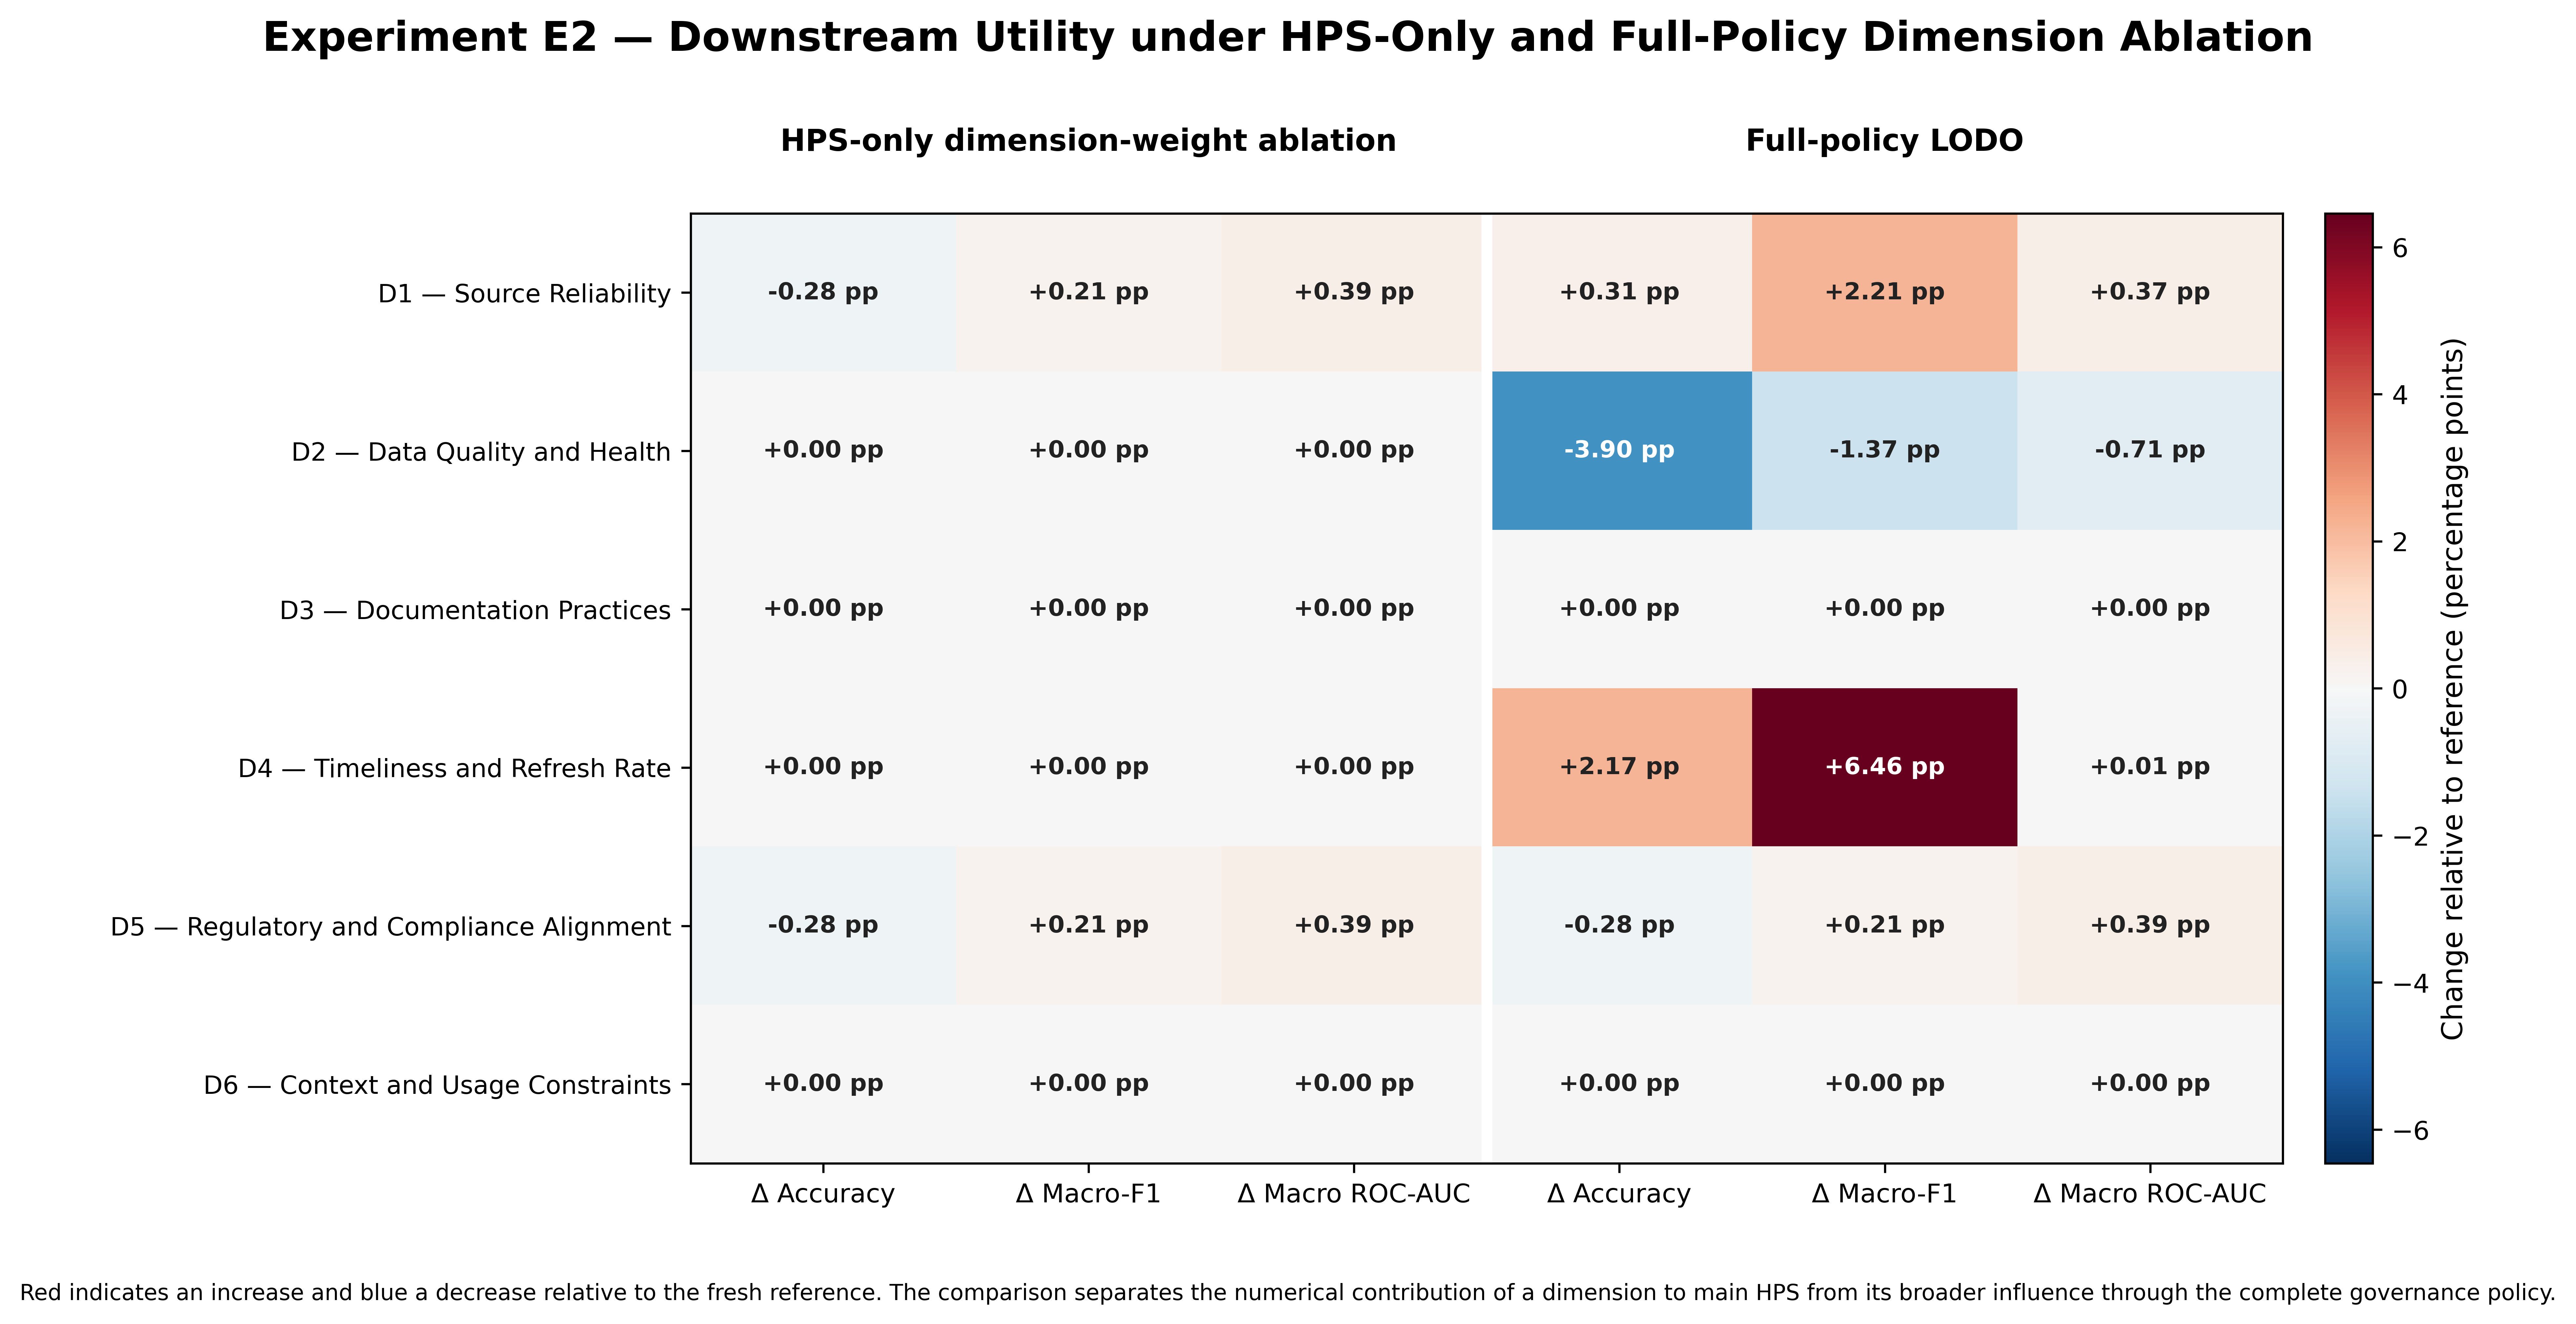


EXPERIMENT E2 COMPLETE

Experiment version:
TADP-E2-FINAL-HPS-ONLY-vs-FULLPOLICY-LODO-K10-5SEED-4ROUND

Reference cohort:
A;B;G;H;I;J

HPS-only cohorts:


,Dimension,HPS_Only_Cohort,HPS_Only_Admitted,HPS_Only_Delta_Admission_pp
0,D1,A;B;E;G;H;I;J,7,10.0
1,D2,A;B;G;H;I;J,6,0.0
2,D3,A;B;G;H;I;J,6,0.0
3,D4,A;B;G;H;I;J,6,0.0
4,D5,A;B;E;G;H;I;J,7,10.0
5,D6,A;B;G;H;I;J,6,0.0



Full-policy LODO cohorts:


,Dimension,Full_LODO_Cohort,Full_LODO_Admitted,Full_LODO_Delta_Admission_pp
0,D1,A;B;E;F;G;H;I;J,8,20.0
1,D2,B;G;I;J,4,-20.0
2,D3,A;B;G;H;I;J,6,0.0
3,D4,A;B;C;G;H;I;J,7,10.0
4,D5,A;B;E;G;H;I;J,7,10.0
5,D6,A;B;G;H;I;J,6,0.0



Observed mechanism patterns:


,Dimension,Dimension_Name,Observed_Mechanism_Pattern
0,D1,Source Reliability,"Both alter admission, but full-policy removal ..."
1,D2,Data Quality and Health,Effect emerges only under full-policy removal
2,D3,Documentation Practices,No admission change under either ablation
3,D4,Timeliness and Refresh Rate,Effect emerges only under full-policy removal
4,D5,Regulatory and Compliance Alignment,Admission effect reproduced by main-HPS ablation
5,D6,Context and Usage Constraints,No admission change under either ablation



Generated files:
  /content/Experiment_E2_HPS_Only_vs_Full_LODO_Summary.csv
  /content/Experiment_E2_HPS_Only_Client_Level.csv
  /content/Experiment_E2_HPS_Only_vs_Full_LODO_Admission.png
  /content/Experiment_E2_HPS_Only_vs_Full_LODO_Utility_Heatmap.png

PNG = 600 DPI
PDF = vector

FINAL ZIP:
/content/Experiment_E2_HPS_Only_vs_Full_LODO_RESULTS.zip



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# ======================================================================================
# TADP EXPERIMENT E2
# HPS-ONLY DIMENSION-WEIGHT ABLATION vs FULL-POLICY LODO
# ======================================================================================
#
# FINAL CORRECTED SINGLE-CELL VERSION
#
# PURPOSE
# -------
# Distinguish TWO mechanisms through which a governance dimension can influence
# TADP admission:
#
# A) HPS-ONLY DIMENSION-WEIGHT ABLATION
#    --------------------------------------------------
#    For each dimension Dj:
#
#        w_j = 0 in the MAIN HPS only
#
#    The remaining main-HPS weights are renormalized to sum to 1.
#
#    EVERYTHING ELSE REMAINS ACTIVE:
#       - all 28 evidence-validity checks
#       - all six dimension-floor checks
#       - all six dimensions remain in the governance policy
#       - HPS_review remains the frozen reference definition
#       - HPS_review still uses D1, D2, D5, D6
#       - HPS_review weights remain unchanged
#       - all thresholds remain frozen
#
#
# B) FULL-POLICY LEAVE-ONE-DIMENSION-OUT (LODO)
#    --------------------------------------------------
#    Uses the FINAL official Experiment-E LODO results:
#
#       - target dimension removed from main HPS
#       - target dimension removed from dimension-floor enforcement
#       - its factors removed from evidence-validity evaluation
#       - if critical, removed from HPS_review
#       - remaining applicable weights renormalized
#
#
# RESEARCH QUESTION
# -----------------
# Does dimension influence arise mainly from:
#
#    1) its numerical contribution to the main HPS?
#
# or
#
#    2) its broader role in the complete governance admission policy?
#
#
# SPEED / REUSE RULE
# ------------------
# The cell loads the FINAL Experiment-E result ZIP.
#
# It computes the six HPS-only governance ablations fresh.
#
# For predictive utility:
#    - if the resulting admitted cohort already has FIVE fresh Experiment-E
#      training runs, those fresh within-Experiment-E runs are reused.
#
#    - if an HPS-only ablation produces a NEW cohort that was never trained
#      inside final Experiment E, the cell STOPS.
#
# No predictive result is invented.
#
#
# FINAL POLICY
# ------------
# K = 10
# Seeds = [42, 142, 242, 342, 442]
# FL rounds = 4
#
# Main HPS weights:
#    D1 = 0.25
#    D2 = 0.15
#    D3 = 0.10
#    D4 = 0.10
#    D5 = 0.30
#    D6 = 0.10
#
# Evidence validity:
#    all 28 active factor scores must be present, finite, and > 0
#
# Dimension floor:
#    every active dimension >= 2.5 / 5
#
# Main HPS:
#    HPS < 3.0             -> REJECT
#    3.0 <= HPS < 3.5     -> automated HPS_review
#    HPS >= 3.5            -> DIRECT ACCEPT
#
# HPS_review:
#    critical dimensions = D1, D2, D5, D6
#    HPS_review >= 3.25    -> ACCEPT
#    otherwise             -> REJECT
#
#
# OUTPUT
# ------
# CSV:
#    Experiment_E2_HPS_Only_vs_Full_LODO_Summary.csv
#    Experiment_E2_HPS_Only_Client_Level.csv
#
# FIGURE 1:
#    Experiment_E2_HPS_Only_vs_Full_LODO_Admission.png
#
# FIGURE 2:
#    Experiment_E2_HPS_Only_vs_Full_LODO_Utility_Heatmap.png
#
# Plus vector PDFs and final ZIP.
# ======================================================================================


# ======================================================================================
# 1. IMPORTS
# ======================================================================================

import os
import math
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm


# ======================================================================================
# 2. EXPERIMENT CONSTANTS
# ======================================================================================

EXPERIMENT_VERSION = (
    "TADP-E2-FINAL-HPS-ONLY-vs-FULLPOLICY-LODO-K10-5SEED-4ROUND"
)

K_SUBMISSIONS = 10

TRAINING_RUN_SEEDS = [
    42,
    142,
    242,
    342,
    442,
]

DIMS = [
    "dim1",
    "dim2",
    "dim3",
    "dim4",
    "dim5",
    "dim6",
]

DIMENSION_NAMES = {
    "dim1": "Source Reliability",
    "dim2": "Data Quality and Health",
    "dim3": "Documentation Practices",
    "dim4": "Timeliness and Refresh Rate",
    "dim5": "Regulatory and Compliance Alignment",
    "dim6": "Context and Usage Constraints",
}

FACTOR_COUNTS = {
    "dim1": 4,
    "dim2": 8,
    "dim3": 4,
    "dim4": 3,
    "dim5": 5,
    "dim6": 4,
}

TOTAL_FACTOR_COUNT = sum(
    FACTOR_COUNTS.values()
)

REFERENCE_HPS_WEIGHTS = {
    "dim1": 0.25,
    "dim2": 0.15,
    "dim3": 0.10,
    "dim4": 0.10,
    "dim5": 0.30,
    "dim6": 0.10,
}

CRITICAL_REVIEW_DIMS = [
    "dim1",
    "dim2",
    "dim5",
    "dim6",
]

# Frozen reference HPS_review weights.
# IMPORTANT:
# HPS-only ablation changes MAIN HPS only.
# These review weights DO NOT change.
CRITICAL_REVIEW_WEIGHTS = {
    d: (
        REFERENCE_HPS_WEIGHTS[d]
        /
        sum(
            REFERENCE_HPS_WEIGHTS[q]
            for q in CRITICAL_REVIEW_DIMS
        )
    )
    for d in CRITICAL_REVIEW_DIMS
}

LOWER_CUT = 3.0
UPPER_CUT = 3.5
REVIEW_CUT = 3.25
DIMENSION_FLOOR = 2.5

DPI = 600

matplotlib.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
})

OUT_DIR = (
    "/content"
    if os.path.isdir("/content")
    else "."
)


# ======================================================================================
# 3. UPLOAD FINAL EXPERIMENT-E RESULTS ZIP
# ======================================================================================

try:
    from google.colab import files
except Exception:
    raise RuntimeError(
        "This cell is intended to run in Google Colab."
    )

print("📤 Upload the FINAL Experiment-E RESULTS.zip")

uploaded = files.upload()

if len(uploaded) != 1:
    raise RuntimeError(
        "Please upload exactly one final Experiment-E ZIP."
    )

uploaded_name = next(
    iter(uploaded.keys())
)

if not uploaded_name.lower().endswith(".zip"):
    raise RuntimeError(
        "The uploaded file must be a ZIP."
    )

uploaded_zip = os.path.join(
    OUT_DIR,
    uploaded_name,
)

with open(
    uploaded_zip,
    "wb",
) as f:
    f.write(
        uploaded[
            uploaded_name
        ]
    )


# ======================================================================================
# 4. EXTRACT FINAL EXPERIMENT-E PACKAGE
# ======================================================================================

extract_dir = Path(
    tempfile.mkdtemp(
        prefix="TADP_E2_INPUT_"
    )
)

with zipfile.ZipFile(
    uploaded_zip,
    "r",
) as zf:
    zf.extractall(
        extract_dir
    )

print("\n✅ Extracted final Experiment E:")
print(extract_dir)


# ======================================================================================
# 5. REQUIRED-FILE LOCATOR
# ======================================================================================

def find_required_file(name):

    matches = list(
        extract_dir.rglob(
            name
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"Required Experiment-E file not found:\n{name}"
        )

    if len(matches) > 1:
        print(
            f"⚠ Multiple '{name}' files found; using:"
        )
        print(
            matches[0]
        )

    return matches[0]


# ======================================================================================
# 6. LOAD FINAL EXPERIMENT-E ARTIFACTS
# ======================================================================================

factor_path = find_required_file(
    "all_28_factor_evidence_by_client.csv"
)

impact_path = find_required_file(
    "policy_admission_utility_impact_vs_fresh_reference.csv"
)

performance_path = find_required_file(
    "fresh_unique_cohort_performance.csv"
)

lodo_matches = list(
    extract_dir.rglob(
        "LODO_dimension_sensitivity_summary.csv"
    )
)

factor_table = pd.read_csv(
    factor_path
)

policy_impact = pd.read_csv(
    impact_path
)

performance = pd.read_csv(
    performance_path
)

if lodo_matches:

    lodo_official = pd.read_csv(
        lodo_matches[0]
    )

else:

    print(
        "⚠ Dedicated LODO table not found; "
        "using official LODO rows from the main impact table."
    )

    lodo_official = policy_impact.loc[
        policy_impact[
            "family"
        ]
        .astype(str)
        .str.upper()
        .eq("LODO")
    ].copy()


print("\n✅ Loaded final Experiment-E artifacts")

print(
    "   Factor evidence:",
    factor_path,
)

print(
    "   Policy impact:",
    impact_path,
)

print(
    "   Fresh cohort performance:",
    performance_path,
)


# ======================================================================================
# 7. VALIDATE FACTOR TABLE
# ======================================================================================

required_factor_columns = {
    "client",
    "dimension",
    "rubric_score_0_5",
}

missing = (
    required_factor_columns
    - set(
        factor_table.columns
    )
)

if missing:
    raise RuntimeError(
        "Factor table missing required columns: "
        + ", ".join(
            sorted(missing)
        )
    )


# ======================================================================================
# 8. RECONSTRUCT SIX DIMENSION SCORES
# ======================================================================================

dim_scores = (
    factor_table

    .groupby(
        [
            "client",
            "dimension",
        ]
    )[
        "rubric_score_0_5"
    ]

    .mean()

    .unstack(
        "dimension"
    )

    .reindex(
        columns=DIMS
    )

    .sort_index()
)

if dim_scores.isna().any().any():
    raise RuntimeError(
        "Unable to reconstruct all six dimension scores."
    )


# ======================================================================================
# 9. COHORT-KEY NORMALIZATION
# ======================================================================================

def normalize_cohort_key(value):

    if pd.isna(value):
        return ""

    values = [
        x.strip()
        for x in (
            str(value)
            .replace(",", ";")
            .split(";")
        )
        if x.strip()
    ]

    return ";".join(
        sorted(values)
    )


# ======================================================================================
# 10. GET OFFICIAL FRESH EXPERIMENT-E REFERENCE
# ======================================================================================

reference_rows = policy_impact.loc[
    policy_impact[
        "configuration"
    ]
    .astype(str)
    .str.upper()
    .eq("REFERENCE")
].copy()

if reference_rows.empty:
    raise RuntimeError(
        "Experiment-E REFERENCE row not found."
    )

reference_row = reference_rows.iloc[0]

REFERENCE_N = int(
    round(
        float(
            reference_row[
                "accepted_count"
            ]
        )
    )
)

if "cohort_key" in reference_row.index:

    REFERENCE_COHORT_KEY = normalize_cohort_key(
        reference_row[
            "cohort_key"
        ]
    )

elif "admitted_clients" in reference_row.index:

    REFERENCE_COHORT_KEY = normalize_cohort_key(
        reference_row[
            "admitted_clients"
        ]
    )

else:

    raise RuntimeError(
        "REFERENCE row contains no cohort identifier."
    )

REFERENCE_COHORT = (
    REFERENCE_COHORT_KEY
    .split(";")
)

REFERENCE_ADMISSION_PCT = (
    100.0
    * REFERENCE_N
    / K_SUBMISSIONS
)

print(
    "\n"
    + "=" * 110
)

print(
    "OFFICIAL FRESH EXPERIMENT-E REFERENCE"
)

print(
    "=" * 110
)

print(
    "Cohort:",
    REFERENCE_COHORT,
)

print(
    f"Admission: "
    f"{REFERENCE_N}/{K_SUBMISSIONS} "
    f"= {REFERENCE_ADMISSION_PCT:.1f}%"
)


# ======================================================================================
# 11. TRUE HPS-ONLY POLICY EVALUATOR
# ======================================================================================
#
# ONLY MAIN HPS is modified.
#
# EVERYTHING ELSE REMAINS FROZEN:
#
#   - all 28 evidence-validity checks
#   - all six dimension floors
#   - HPS_review dimensions
#   - HPS_review weights
#   - lower / upper / review thresholds
#
# ======================================================================================

def evaluate_hps_only_policy(
    zero_hps_dimension=None
):

    # ------------------------------------------------------------------
    # MAIN-HPS WEIGHTS
    # ------------------------------------------------------------------

    main_weights = dict(
        REFERENCE_HPS_WEIGHTS
    )

    if zero_hps_dimension is not None:

        if zero_hps_dimension not in DIMS:
            raise ValueError(
                zero_hps_dimension
            )

        main_weights[
            zero_hps_dimension
        ] = 0.0

        weight_sum = sum(
            main_weights.values()
        )

        if weight_sum <= 0:
            raise RuntimeError(
                "Invalid HPS-only weight vector."
            )

        main_weights = {
            d: (
                main_weights[d]
                / weight_sum
            )
            for d in DIMS
        }

    rows = []

    # ------------------------------------------------------------------
    # EVALUATE ALL K=10 CONTRIBUTORS
    # ------------------------------------------------------------------

    for client in dim_scores.index.astype(str):

        client_factors = factor_table.loc[
            factor_table[
                "client"
            ]
            .astype(str)
            .eq(client)
        ].copy()

        values = pd.to_numeric(
            client_factors[
                "rubric_score_0_5"
            ],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

        # --------------------------------------------------------------
        # GATE 1 — ALL 28 FACTORS REMAIN ACTIVE
        # --------------------------------------------------------------

        evidence_validity_pass = bool(
            len(client_factors)
            == TOTAL_FACTOR_COUNT

            and

            np.all(
                np.isfinite(values)
            )

            and

            np.all(
                values > 0.0
            )
        )

        ds = dim_scores.loc[
            client
        ]

        # --------------------------------------------------------------
        # GATE 2 — ALL SIX DIMENSION FLOORS REMAIN ACTIVE
        # --------------------------------------------------------------

        floor_failures = [
            d
            for d in DIMS
            if (
                not np.isfinite(
                    float(
                        ds[d]
                    )
                )

                or

                float(
                    ds[d]
                )
                < DIMENSION_FLOOR
            )
        ]

        # --------------------------------------------------------------
        # MAIN HPS
        # ONLY THIS CHANGES IN HPS-ONLY ABLATION
        # --------------------------------------------------------------

        hps = float(
            sum(
                float(
                    ds[d]
                )
                * main_weights[d]

                for d in DIMS
            )
        )

        # --------------------------------------------------------------
        # HPS_review
        # FROZEN REFERENCE DEFINITION
        # --------------------------------------------------------------

        hps_review = float(
            sum(
                float(
                    ds[d]
                )
                * CRITICAL_REVIEW_WEIGHTS[d]

                for d in CRITICAL_REVIEW_DIMS
            )
        )

        # --------------------------------------------------------------
        # FINAL POLICY DECISION
        # --------------------------------------------------------------

        if not evidence_validity_pass:

            final_action = "REJECT"

            decision_path = (
                "EVIDENCE_VALIDITY_GATE"
            )

            status = (
                "AUTO_REJECTED_EVIDENCE_VALIDITY"
            )

        elif floor_failures:

            final_action = "REJECT"

            decision_path = (
                "DIMENSION_FLOOR"
            )

            status = (
                "AUTO_REJECTED_DIMENSION_FLOOR"
            )

        elif hps < LOWER_CUT:

            final_action = "REJECT"

            decision_path = (
                "LOW_HPS"
            )

            status = (
                "AUTO_REJECTED_LOW_HPS"
            )

        elif hps >= UPPER_CUT:

            final_action = "ACCEPT"

            decision_path = (
                "DIRECT_AUTO_ACCEPT"
            )

            status = (
                "DIRECT_AUTO_ACCEPTED"
            )

        else:

            decision_path = (
                "HPS_REVIEW_BAND"
            )

            if hps_review >= REVIEW_CUT:

                final_action = "ACCEPT"

                status = (
                    "ACCEPTED_AFTER_AUTOMATED_REVIEW"
                )

            else:

                final_action = "REJECT"

                status = (
                    "AUTO_REJECTED_HPS_REVIEW"
                )

        rows.append({

            "configuration":
                (
                    "REFERENCE"
                    if zero_hps_dimension is None
                    else
                    f"HPS_ONLY_ZERO_{zero_hps_dimension}"
                ),

            "zero_hps_dimension":
                (
                    ""
                    if zero_hps_dimension is None
                    else zero_hps_dimension
                ),

            "client":
                client,

            "hps":
                hps,

            "hps_review":
                hps_review,

            "evidence_validity_pass":
                evidence_validity_pass,

            "dimension_floor_failures":
                ";".join(
                    floor_failures
                ),

            "decision_path":
                decision_path,

            "status":
                status,

            "final_action":
                final_action,

            "main_hps_weights":
                str(
                    main_weights
                ),

            "hps_review_weights_frozen":
                str(
                    CRITICAL_REVIEW_WEIGHTS
                ),

            **{
                f"{d}_score_0_5":
                    float(
                        ds[d]
                    )
                for d in DIMS
            },
        })

    return pd.DataFrame(
        rows
    )


# ======================================================================================
# 12. VERIFY REFERENCE-POLICY RECONSTRUCTION
# ======================================================================================

reference_check = evaluate_hps_only_policy(
    zero_hps_dimension=None
)

calculated_reference = (
    reference_check.loc[
        reference_check[
            "final_action"
        ]
        .eq("ACCEPT"),
        "client",
    ]
    .astype(str)
    .tolist()
)

calculated_reference_key = normalize_cohort_key(
    ";".join(
        calculated_reference
    )
)

if calculated_reference_key != REFERENCE_COHORT_KEY:

    raise RuntimeError(
        "FAIL-CLOSED: reconstructed policy does not reproduce "
        "the official Experiment-E reference cohort.\n\n"
        f"Official:   {REFERENCE_COHORT_KEY}\n"
        f"Calculated: {calculated_reference_key}"
    )

print(
    "\n✅ Reference-policy reconstruction audit: PASS"
)


# ======================================================================================
# 13. RUN SIX HPS-ONLY DIMENSION-WEIGHT ABLATIONS
# ======================================================================================

hps_only_summary_rows = []

hps_only_client_frames = []

reference_action_map = dict(
    zip(
        reference_check[
            "client"
        ]
        .astype(str),

        reference_check[
            "final_action"
        ]
        .astype(str),
    )
)

for dim in DIMS:

    current = evaluate_hps_only_policy(
        zero_hps_dimension=dim
    )

    current.insert(
        1,
        "dimension_name",
        DIMENSION_NAMES[
            dim
        ],
    )

    hps_only_client_frames.append(
        current
    )

    admitted = (
        current.loc[
            current[
                "final_action"
            ]
            .eq("ACCEPT"),
            "client",
        ]
        .astype(str)
        .tolist()
    )

    cohort_key = normalize_cohort_key(
        ";".join(
            admitted
        )
    )

    current_action_map = dict(
        zip(
            current[
                "client"
            ]
            .astype(str),

            current[
                "final_action"
            ]
            .astype(str),
        )
    )

    flips = [
        client
        for client in reference_action_map
        if (
            reference_action_map[
                client
            ]
            !=
            current_action_map[
                client
            ]
        )
    ]

    gained = sorted(
        set(
            admitted
        )
        -
        set(
            REFERENCE_COHORT
        )
    )

    lost = sorted(
        set(
            REFERENCE_COHORT
        )
        -
        set(
            admitted
        )
    )

    hps_only_summary_rows.append({

        "dimension":
            dim,

        "dimension_name":
            DIMENSION_NAMES[
                dim
            ],

        "reference_weight":
            REFERENCE_HPS_WEIGHTS[
                dim
            ],

        "cohort_key":
            cohort_key,

        "accepted_count":
            len(
                admitted
            ),

        "admission_rate_pct":
            (
                100.0
                * len(
                    admitted
                )
                / K_SUBMISSIONS
            ),

        "delta_admission_pp":
            (
                100.0
                * (
                    len(
                        admitted
                    )
                    - REFERENCE_N
                )
                / K_SUBMISSIONS
            ),

        "gained_clients":
            ";".join(
                gained
            ),

        "lost_clients":
            ";".join(
                lost
            ),

        "decision_flip_count":
            len(
                flips
            ),

        "decision_flip_clients":
            ";".join(
                flips
            ),
    })


hps_only_summary = pd.DataFrame(
    hps_only_summary_rows
)

hps_only_client_level = pd.concat(
    hps_only_client_frames,
    ignore_index=True,
)


# ======================================================================================
# 14. PREPARE FRESH EXPERIMENT-E COHORT PERFORMANCE
# ======================================================================================

required_perf_columns = {
    "seed",
    "cohort_key",
    "accuracy",
    "f1_macro",
    "roc_auc_ovr_macro",
}

missing = (
    required_perf_columns
    - set(
        performance.columns
    )
)

if missing:
    raise RuntimeError(
        "Fresh cohort-performance table missing columns: "
        + ", ".join(
            sorted(missing)
        )
    )


performance[
    "normalized_cohort_key"
] = performance[
    "cohort_key"
].apply(
    normalize_cohort_key
)


# ======================================================================================
# 15. VERIFY FIVE-SEED REFERENCE PERFORMANCE
# ======================================================================================

reference_perf = performance.loc[
    performance[
        "normalized_cohort_key"
    ]
    .eq(
        REFERENCE_COHORT_KEY
    )
].copy()

reference_perf = (
    reference_perf

    .drop_duplicates(
        subset=[
            "seed"
        ]
    )

    .sort_values(
        "seed"
    )

    .reset_index(
        drop=True
    )
)

if sorted(
    reference_perf[
        "seed"
    ]
    .astype(int)
    .tolist()
) != TRAINING_RUN_SEEDS:

    raise RuntimeError(
        "Fresh Experiment-E reference does not contain "
        "the expected five training seeds."
    )


# ======================================================================================
# 16. PAIRED UTILITY DELTA FUNCTION
# ======================================================================================

def paired_utility_delta(
    cohort_key
):

    cohort_key = normalize_cohort_key(
        cohort_key
    )

    current = performance.loc[
        performance[
            "normalized_cohort_key"
        ]
        .eq(
            cohort_key
        )
    ].copy()

    if current.empty:
        return None

    current = (
        current

        .drop_duplicates(
            subset=[
                "seed"
            ]
        )

        .sort_values(
            "seed"
        )

        .reset_index(
            drop=True
        )
    )

    merged = current.merge(
        reference_perf,
        on="seed",
        suffixes=(
            "_current",
            "_reference",
        ),
        validate="one_to_one",
    )

    if sorted(
        merged[
            "seed"
        ]
        .astype(int)
        .tolist()
    ) != TRAINING_RUN_SEEDS:

        return None

    delta_accuracy = (
        merged[
            "accuracy_current"
        ]
        .to_numpy(
            dtype=float
        )
        -
        merged[
            "accuracy_reference"
        ]
        .to_numpy(
            dtype=float
        )
    )

    delta_f1 = (
        merged[
            "f1_macro_current"
        ]
        .to_numpy(
            dtype=float
        )
        -
        merged[
            "f1_macro_reference"
        ]
        .to_numpy(
            dtype=float
        )
    )

    delta_auc = (
        merged[
            "roc_auc_ovr_macro_current"
        ]
        .to_numpy(
            dtype=float
        )
        -
        merged[
            "roc_auc_ovr_macro_reference"
        ]
        .to_numpy(
            dtype=float
        )
    )

    return {

        "delta_accuracy_mean":
            float(
                np.mean(
                    delta_accuracy
                )
            ),

        "delta_accuracy_sd":
            float(
                np.std(
                    delta_accuracy,
                    ddof=1,
                )
            ),

        "delta_f1_macro_mean":
            float(
                np.mean(
                    delta_f1
                )
            ),

        "delta_f1_macro_sd":
            float(
                np.std(
                    delta_f1,
                    ddof=1,
                )
            ),

        "delta_roc_auc_ovr_macro_mean":
            float(
                np.mean(
                    delta_auc
                )
            ),

        "delta_roc_auc_ovr_macro_sd":
            float(
                np.std(
                    delta_auc,
                    ddof=1,
                )
            ),
    }


# ======================================================================================
# 17. MAP HPS-ONLY COHORTS TO EXISTING FRESH EXPERIMENT-E TRAINING RUNS
# ======================================================================================

missing_hps_only_cohorts = []

utility_rows = []

for row in hps_only_summary.itertuples(
    index=False
):

    utility = paired_utility_delta(
        row.cohort_key
    )

    if utility is None:

        missing_hps_only_cohorts.append({

            "dimension":
                row.dimension,

            "cohort_key":
                row.cohort_key,
        })

    else:

        utility_rows.append({

            "dimension":
                row.dimension,

            **utility,
        })


# FAIL CLOSED:
# governance remains valid, but predictive metrics are not invented.
if missing_hps_only_cohorts:

    missing_df = pd.DataFrame(
        missing_hps_only_cohorts
    )

    missing_path = os.path.join(
        OUT_DIR,
        "Experiment_E2_NEW_COHORTS_REQUIRING_TRAINING.csv",
    )

    missing_df.to_csv(
        missing_path,
        index=False,
    )

    print(
        "\n"
        + "!" * 110
    )

    print(
        "NEW HPS-ONLY COHORT DETECTED — PREDICTIVE TRAINING REQUIRED"
    )

    print(
        "!" * 110
    )

    display(
        missing_df
    )

    raise RuntimeError(
        "At least one HPS-only ablation produced a cohort "
        "that was not freshly trained in final Experiment E. "
        "No downstream utility was fabricated."
    )


hps_utility = pd.DataFrame(
    utility_rows
)

hps_only_summary = hps_only_summary.merge(
    hps_utility,
    on="dimension",
    how="left",
    validate="one_to_one",
)


print(
    "\n✅ All HPS-only cohorts already have five fresh Experiment-E training runs."
)

print(
    "   No additional model training is required."
)


# ======================================================================================
# 18. PREPARE OFFICIAL FULL-POLICY LODO RESULTS
# ======================================================================================

if "removed_dimension" not in lodo_official.columns:

    if "configuration" not in lodo_official.columns:
        raise RuntimeError(
            "Cannot identify removed LODO dimensions."
        )

    lodo_official[
        "removed_dimension"
    ] = (
        lodo_official[
            "configuration"
        ]
        .astype(str)
        .str.extract(
            r"(dim[1-6])",
            expand=False,
        )
    )


lodo_official[
    "removed_dimension"
] = (
    lodo_official[
        "removed_dimension"
    ]
    .astype(str)
    .str.lower()
)


lodo_official = (
    lodo_official

    .drop_duplicates(
        subset=[
            "removed_dimension"
        ]
    )

    .set_index(
        "removed_dimension"
    )

    .reindex(
        DIMS
    )

    .reset_index()
)


if lodo_official[
    "accepted_count"
].isna().any():

    raise RuntimeError(
        "Official final Experiment-E LODO table is incomplete."
    )


# IMPORTANT FIX:
# use a normal Pandas-safe column name.
# Do NOT use "_cohort_key" with itertuples().
if "cohort_key" in lodo_official.columns:

    lodo_official[
        "normalized_cohort_key"
    ] = (
        lodo_official[
            "cohort_key"
        ]
        .apply(
            normalize_cohort_key
        )
    )

elif "admitted_clients" in lodo_official.columns:

    lodo_official[
        "normalized_cohort_key"
    ] = (
        lodo_official[
            "admitted_clients"
        ]
        .apply(
            normalize_cohort_key
        )
    )

else:

    raise RuntimeError(
        "LODO table contains no cohort identifier."
    )


print(
    "\n✅ Official full-policy LODO cohorts loaded:"
)

display(
    lodo_official[[
        "removed_dimension",
        "accepted_count",
        "normalized_cohort_key",
    ]]
)


# ======================================================================================
# 19. AUDIT FULL-POLICY LODO UTILITY AGAINST FRESH COHORT PERFORMANCE
# ======================================================================================

lodo_recomputed_rows = []

for row in lodo_official.itertuples(
    index=False
):

    dim = str(
        row.removed_dimension
    )

    # CORRECTED:
    cohort_key = str(
        row.normalized_cohort_key
    )

    utility = paired_utility_delta(
        cohort_key
    )

    if utility is None:

        raise RuntimeError(
            f"Official LODO {dim} cohort does not map to a "
            "complete five-seed fresh Experiment-E cohort result.\n"
            f"Cohort: {cohort_key}"
        )

    lodo_recomputed_rows.append({

        "dimension":
            dim,

        "cohort_key":
            cohort_key,

        **utility,
    })


lodo_recomputed = pd.DataFrame(
    lodo_recomputed_rows
)


print(
    "\n✅ Full-policy LODO five-seed utility audit: PASS"
)


# ======================================================================================
# 20. BUILD FINAL HPS-ONLY vs FULL-POLICY LODO SUMMARY
# ======================================================================================

final_rows = []

for dim in DIMS:

    # ------------------------------------------------------------------
    # HPS-ONLY GOVERNANCE + UTILITY
    # ------------------------------------------------------------------

    h = hps_only_summary.loc[
        hps_only_summary[
            "dimension"
        ]
        .eq(dim)
    ].iloc[0]

    # ------------------------------------------------------------------
    # OFFICIAL LODO GOVERNANCE
    # ------------------------------------------------------------------

    l = lodo_official.loc[
        lodo_official[
            "removed_dimension"
        ]
        .eq(dim)
    ].iloc[0]

    # ------------------------------------------------------------------
    # RECOMPUTED PAIRED LODO UTILITY
    # ------------------------------------------------------------------

    lu = lodo_recomputed.loc[
        lodo_recomputed[
            "dimension"
        ]
        .eq(dim)
    ].iloc[0]

    lodo_n = int(
        round(
            float(
                l[
                    "accepted_count"
                ]
            )
        )
    )

    hps_cohort_key = normalize_cohort_key(
        h[
            "cohort_key"
        ]
    )

    lodo_cohort_key = normalize_cohort_key(
        l[
            "normalized_cohort_key"
        ]
    )

    final_rows.append({

        # ==============================================================
        # DIMENSION
        # ==============================================================

        "Dimension":
            dim.upper()
            .replace(
                "DIM",
                "D"
            ),

        "Dimension_Name":
            DIMENSION_NAMES[
                dim
            ],

        "Reference_HPS_Weight":
            REFERENCE_HPS_WEIGHTS[
                dim
            ],


        # ==============================================================
        # HPS-ONLY
        # ==============================================================

        "HPS_Only_Cohort":
            hps_cohort_key,

        "HPS_Only_Admitted":
            int(
                h[
                    "accepted_count"
                ]
            ),

        "HPS_Only_Delta_Admission_pp":
            float(
                h[
                    "delta_admission_pp"
                ]
            ),

        "HPS_Only_Delta_Accuracy_pp":
            (
                100.0
                * float(
                    h[
                        "delta_accuracy_mean"
                    ]
                )
            ),

        "HPS_Only_Delta_MacroF1_pp":
            (
                100.0
                * float(
                    h[
                        "delta_f1_macro_mean"
                    ]
                )
            ),

        "HPS_Only_Delta_MacroAUC_pp":
            (
                100.0
                * float(
                    h[
                        "delta_roc_auc_ovr_macro_mean"
                    ]
                )
            ),


        # ==============================================================
        # FULL-POLICY LODO
        # ==============================================================

        "Full_LODO_Cohort":
            lodo_cohort_key,

        "Full_LODO_Admitted":
            lodo_n,

        "Full_LODO_Delta_Admission_pp":
            (
                100.0
                * (
                    lodo_n
                    - REFERENCE_N
                )
                / K_SUBMISSIONS
            ),

        "Full_LODO_Delta_Accuracy_pp":
            (
                100.0
                * float(
                    lu[
                        "delta_accuracy_mean"
                    ]
                )
            ),

        "Full_LODO_Delta_MacroF1_pp":
            (
                100.0
                * float(
                    lu[
                        "delta_f1_macro_mean"
                    ]
                )
            ),

        "Full_LODO_Delta_MacroAUC_pp":
            (
                100.0
                * float(
                    lu[
                        "delta_roc_auc_ovr_macro_mean"
                    ]
                )
            ),


        # ==============================================================
        # MECHANISM FLAGS
        # ==============================================================

        "HPS_Only_Changed_Cohort":
            bool(
                hps_cohort_key
                != REFERENCE_COHORT_KEY
            ),

        "Full_LODO_Changed_Cohort":
            bool(
                lodo_cohort_key
                != REFERENCE_COHORT_KEY
            ),

        "Same_Cohort_Under_Both_Ablations":
            bool(
                hps_cohort_key
                == lodo_cohort_key
            ),
    })


final_summary = pd.DataFrame(
    final_rows
)


# ======================================================================================
# 21. DESCRIPTIVE MECHANISM CLASSIFICATION
# ======================================================================================

def mechanism_pattern(
    row
):

    hps_changed = bool(
        row[
            "HPS_Only_Changed_Cohort"
        ]
    )

    lodo_changed = bool(
        row[
            "Full_LODO_Changed_Cohort"
        ]
    )

    same = bool(
        row[
            "Same_Cohort_Under_Both_Ablations"
        ]
    )

    if (
        not hps_changed
        and
        not lodo_changed
    ):

        return (
            "No admission change under either ablation"
        )

    if (
        hps_changed
        and
        lodo_changed
        and
        same
    ):

        return (
            "Admission effect reproduced by main-HPS ablation"
        )

    if (
        hps_changed
        and
        lodo_changed
        and
        not same
    ):

        return (
            "Both alter admission, but full-policy removal differs"
        )

    if (
        not hps_changed
        and
        lodo_changed
    ):

        return (
            "Effect emerges only under full-policy removal"
        )

    if (
        hps_changed
        and
        not lodo_changed
    ):

        return (
            "Main-HPS ablation changes admission; full removal compensates"
        )

    return (
        "Mixed response"
    )


final_summary[
    "Observed_Mechanism_Pattern"
] = final_summary.apply(
    mechanism_pattern,
    axis=1,
)


# ======================================================================================
# 22. SAVE NUMERICAL RESULTS
# ======================================================================================

summary_csv = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_Summary.csv",
)

client_csv = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_Client_Level.csv",
)

final_summary.to_csv(
    summary_csv,
    index=False,
)

hps_only_client_level.to_csv(
    client_csv,
    index=False,
)


# ======================================================================================
# 23. DISPLAY FINAL NUMERICAL SUMMARY
# ======================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "EXPERIMENT E2 — HPS-ONLY ABLATION vs FULL-POLICY LODO"
)

print(
    "=" * 120
)

display(
    final_summary[[
        "Dimension",
        "Dimension_Name",

        "HPS_Only_Admitted",
        "HPS_Only_Delta_Admission_pp",

        "Full_LODO_Admitted",
        "Full_LODO_Delta_Admission_pp",

        "HPS_Only_Delta_Accuracy_pp",
        "Full_LODO_Delta_Accuracy_pp",

        "HPS_Only_Delta_MacroF1_pp",
        "Full_LODO_Delta_MacroF1_pp",

        "HPS_Only_Delta_MacroAUC_pp",
        "Full_LODO_Delta_MacroAUC_pp",

        "Observed_Mechanism_Pattern",
    ]]
    .round(4)
)


# ======================================================================================
# FIGURE 1
# ADMISSION EFFECT — HPS-ONLY vs FULL-POLICY LODO
# ======================================================================================

COLOR_HPS_ONLY = "#4F81BD"
COLOR_FULL_LODO = "#C05A5A"

EDGE = "#4D4D4D"
GRID = "#C8C8C8"

labels = [
    (
        f"{row.Dimension}\n"
        f"{row.Dimension_Name}"
    )
    for row in final_summary.itertuples(
        index=False
    )
]

y = np.arange(
    len(labels)
)

bar_height = 0.34

fig1, ax1 = plt.subplots(
    figsize=(
        11.4,
        7.2,
    ),
    dpi=DPI,
)

bars_hps = ax1.barh(
    y
    - bar_height / 2,

    final_summary[
        "HPS_Only_Delta_Admission_pp"
    ],

    height=bar_height,

    color=COLOR_HPS_ONLY,

    edgecolor=EDGE,

    linewidth=0.7,

    label="HPS-only weight ablation",
)

bars_lodo = ax1.barh(
    y
    + bar_height / 2,

    final_summary[
        "Full_LODO_Delta_Admission_pp"
    ],

    height=bar_height,

    color=COLOR_FULL_LODO,

    edgecolor=EDGE,

    linewidth=0.7,

    label="Full-policy LODO",
)

ax1.axvline(
    0,
    color="#666666",
    linewidth=1.1,
)

ax1.set_yticks(
    y
)

ax1.set_yticklabels(
    labels,
    fontsize=9.2,
)

ax1.invert_yaxis()

ax1.set_xlabel(
    "Change in admission rate relative to reference (percentage points)"
)

ax1.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    color=GRID,
)

ax1.set_axisbelow(
    True
)

ax1.spines[
    "top"
].set_visible(
    False
)

ax1.spines[
    "right"
].set_visible(
    False
)


# ======================================================================================
# 24. SYMMETRIC ADMISSION AXIS
# ======================================================================================

admission_matrix = final_summary[[
    "HPS_Only_Delta_Admission_pp",
    "Full_LODO_Delta_Admission_pp",
]].to_numpy(
    dtype=float
)

max_abs_admission = max(
    10.0,
    float(
        np.nanmax(
            np.abs(
                admission_matrix
            )
        )
    )
)

ax1.set_xlim(
    -max_abs_admission - 7,
    max_abs_admission + 7,
)


# ======================================================================================
# 25. BAR LABELS
# ======================================================================================

for bars in [
    bars_hps,
    bars_lodo,
]:

    for bar in bars:

        value = float(
            bar.get_width()
        )

        if value > 0:

            x_text = (
                value + 0.8
            )

            ha = "left"

        elif value < 0:

            x_text = (
                value - 0.8
            )

            ha = "right"

        else:

            # place zero just to right of zero line
            x_text = 0.8
            ha = "left"

        ax1.text(
            x_text,

            bar.get_y()
            + bar.get_height() / 2,

            f"{value:+.0f} pp",

            va="center",

            ha=ha,

            fontsize=8.8,

            fontweight="bold",
        )


ax1.legend(
    loc="best",
    frameon=True,
)


fig1.suptitle(
    "Experiment E2 — Main-HPS Ablation vs Full-Policy Dimension Removal",
    fontsize=15.5,
    fontweight="bold",
    y=0.975,
)

fig1.text(
    0.5,
    0.935,

    (
        f"Admission sensitivity relative to the fresh reference "
        f"({REFERENCE_N}/{K_SUBMISSIONS} = "
        f"{REFERENCE_ADMISSION_PCT:.0f}% admitted)"
    ),

    ha="center",
    fontsize=10.2,
)

fig1.text(
    0.5,
    0.018,

    (
        "HPS-only sets one main-HPS weight to zero while retaining evidence validity, "
        "all six dimension floors, and the frozen HPS_review. "
        "Full-policy LODO removes the dimension from all applicable policy components."
    ),

    ha="center",
    fontsize=8.0,
)

fig1.subplots_adjust(
    left=0.31,
    right=0.97,
    bottom=0.11,
    top=0.88,
)


admission_png = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_Admission.png",
)

admission_pdf = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_Admission.pdf",
)

fig1.savefig(
    admission_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig1.savefig(
    admission_pdf,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ======================================================================================
# FIGURE 2
# UTILITY HEATMAP — HPS-ONLY vs FULL-POLICY LODO
# ======================================================================================

heatmap_matrix = final_summary[[
    "HPS_Only_Delta_Accuracy_pp",
    "HPS_Only_Delta_MacroF1_pp",
    "HPS_Only_Delta_MacroAUC_pp",

    "Full_LODO_Delta_Accuracy_pp",
    "Full_LODO_Delta_MacroF1_pp",
    "Full_LODO_Delta_MacroAUC_pp",
]].to_numpy(
    dtype=float
)


heatmap_columns = [
    "Δ Accuracy",
    "Δ Macro-F1",
    "Δ Macro ROC-AUC",

    "Δ Accuracy",
    "Δ Macro-F1",
    "Δ Macro ROC-AUC",
]


max_abs_utility = float(
    np.nanmax(
        np.abs(
            heatmap_matrix
        )
    )
)

if (
    not np.isfinite(
        max_abs_utility
    )
    or
    max_abs_utility == 0
):
    max_abs_utility = 1.0


norm = TwoSlopeNorm(
    vmin=-max_abs_utility,
    vcenter=0.0,
    vmax=max_abs_utility,
)


fig2, ax2 = plt.subplots(
    figsize=(
        13.2,
        6.8,
    ),
    dpi=DPI,
)


im = ax2.imshow(
    heatmap_matrix,
    cmap="RdBu_r",
    norm=norm,
    aspect="auto",
)


# ======================================================================================
# 26. HEATMAP AXES
# ======================================================================================

ax2.set_xticks(
    np.arange(6)
)

ax2.set_xticklabels(
    heatmap_columns,
    fontsize=9.5,
)

ax2.set_yticks(
    np.arange(
        len(
            final_summary
        )
    )
)

ax2.set_yticklabels(
    [
        (
            f"{r.Dimension} — "
            f"{r.Dimension_Name}"
        )
        for r in final_summary.itertuples(
            index=False
        )
    ],
    fontsize=9.2,
)


# Strong divider between HPS-only and full LODO
ax2.axvline(
    2.5,
    color="white",
    linewidth=4.0,
)


# ======================================================================================
# 27. HEATMAP GROUP HEADERS
# ======================================================================================

ax2.text(
    1.0,
    -0.95,

    "HPS-only dimension-weight ablation",

    ha="center",
    va="center",

    fontsize=11,
    fontweight="bold",
)

ax2.text(
    4.0,
    -0.95,

    "Full-policy LODO",

    ha="center",
    va="center",

    fontsize=11,
    fontweight="bold",
)


# ======================================================================================
# 28. HEATMAP NUMERICAL VALUES
# ======================================================================================

for i in range(
    heatmap_matrix.shape[0]
):

    for j in range(
        heatmap_matrix.shape[1]
    ):

        value = float(
            heatmap_matrix[
                i,
                j
            ]
        )

        text_color = (
            "white"
            if abs(value)
            >= (
                0.52
                * max_abs_utility
            )
            else "#222222"
        )

        ax2.text(
            j,
            i,

            f"{value:+.2f} pp",

            ha="center",
            va="center",

            fontsize=8.7,
            fontweight="bold",

            color=text_color,
        )


# ======================================================================================
# 29. COLORBAR
# ======================================================================================

cbar = fig2.colorbar(
    im,
    ax=ax2,
    fraction=0.032,
    pad=0.025,
)

cbar.set_label(
    "Change relative to reference (percentage points)",
    fontsize=10.5,
)


fig2.suptitle(
    "Experiment E2 — Downstream Utility under HPS-Only and Full-Policy Dimension Ablation",
    fontsize=15.0,
    fontweight="bold",
    y=0.975,
)

fig2.text(
    0.5,
    0.018,

    (
        "Red indicates an increase and blue a decrease relative to the fresh reference. "
        "The comparison separates the numerical contribution of a dimension to main HPS "
        "from its broader influence through the complete governance policy."
    ),

    ha="center",
    fontsize=8.1,
)

fig2.subplots_adjust(
    left=0.27,
    right=0.92,
    bottom=0.12,
    top=0.83,
)


utility_png = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_Utility_Heatmap.png",
)

utility_pdf = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_Utility_Heatmap.pdf",
)

fig2.savefig(
    utility_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig2.savefig(
    utility_pdf,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ======================================================================================
# 30. SAVE DESIGN DESCRIPTION
# ======================================================================================

readme_path = os.path.join(
    OUT_DIR,
    "Experiment_E2_DESIGN.txt",
)

design_text = f"""
{EXPERIMENT_VERSION}

PURPOSE
-------
Compare main-HPS-only dimension-weight ablation against full-policy
leave-one-dimension-out (LODO).

REFERENCE
---------
K = {K_SUBMISSIONS}
Reference cohort = {REFERENCE_COHORT_KEY}
Reference admission = {REFERENCE_N}/{K_SUBMISSIONS}
Reference admission rate = {REFERENCE_ADMISSION_PCT:.1f}%

HPS-ONLY ABLATION
-----------------
For target dimension Dj:

    main-HPS weight wj = 0

Remaining main-HPS weights are renormalized.

The following remain unchanged:

    - all 28 evidence-validity checks
    - all six dimension-floor checks
    - HPS lower threshold = {LOWER_CUT}
    - HPS upper threshold = {UPPER_CUT}
    - HPS_review threshold = {REVIEW_CUT}
    - HPS_review dimensions = D1, D2, D5, D6
    - HPS_review weights = {CRITICAL_REVIEW_WEIGHTS}

FULL-POLICY LODO
----------------
Official final Experiment-E LODO results are used.

The removed dimension is excluded from all applicable policy components.

PREDICTIVE COMPARISON
---------------------
Predictive deltas are paired by training seed relative to the fresh
Experiment-E reference.

Seeds:
{TRAINING_RUN_SEEDS}

No predictive value is fabricated.

If an HPS-only cohort does not exist among the fresh Experiment-E
five-seed cohort runs, the script fails closed and requests training
of that cohort.
"""

with open(
    readme_path,
    "w",
    encoding="utf-8",
) as f:
    f.write(
        design_text
    )


# ======================================================================================
# 31. PACKAGE FINAL RESULTS
# ======================================================================================

out_zip = os.path.join(
    OUT_DIR,
    "Experiment_E2_HPS_Only_vs_Full_LODO_RESULTS.zip",
)

with zipfile.ZipFile(
    out_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:

    for path in [
        summary_csv,
        client_csv,
        admission_png,
        admission_pdf,
        utility_png,
        utility_pdf,
        readme_path,
    ]:

        zf.write(
            path,
            arcname=os.path.basename(
                path
            ),
        )


# ======================================================================================
# 32. FINAL AUDIT
# ======================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "EXPERIMENT E2 COMPLETE"
)

print(
    "=" * 120
)


print(
    "\nExperiment version:"
)

print(
    EXPERIMENT_VERSION
)


print(
    "\nReference cohort:"
)

print(
    REFERENCE_COHORT_KEY
)


print(
    "\nHPS-only cohorts:"
)

display(
    final_summary[[
        "Dimension",
        "HPS_Only_Cohort",
        "HPS_Only_Admitted",
        "HPS_Only_Delta_Admission_pp",
    ]]
)


print(
    "\nFull-policy LODO cohorts:"
)

display(
    final_summary[[
        "Dimension",
        "Full_LODO_Cohort",
        "Full_LODO_Admitted",
        "Full_LODO_Delta_Admission_pp",
    ]]
)


print(
    "\nObserved mechanism patterns:"
)

display(
    final_summary[[
        "Dimension",
        "Dimension_Name",
        "Observed_Mechanism_Pattern",
    ]]
)


print(
    "\nGenerated files:"
)

print(
    " ",
    summary_csv
)

print(
    " ",
    client_csv
)

print(
    " ",
    admission_png
)

print(
    " ",
    utility_png
)


print(
    "\nPNG = 600 DPI"
)

print(
    "PDF = vector"
)


print(
    "\nFINAL ZIP:"
)

print(
    out_zip
)


# ======================================================================================
# 33. AUTOMATIC DOWNLOAD
# ======================================================================================

print(
    "\nDownloading Experiment E2 result package..."
)

files.download(
    out_zip
)